## Based on the given features predicting Future Flight Price.

## Introduction
This project aims to predict Future Flight Price by developing a machine learning model that can predict flight prices based on historical data. By analyzing features such as the date of journey, departure and arrival times, airlines, and other relevant variables, the model seeks to uncover patterns and trends that influence flight pricing. The goal is to build a predictive tool that not only forecasts future prices but also provides insights into the factors driving these prices.

## Task 1:-Prepare a complete data analysis report on the given data.

## Domain Analysis

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_excel('Flight_Fare.xlsx')

In [3]:
data.shape

(10683, 11)

In [4]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
data.nunique()

Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64

In [7]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
data.dropna(inplace = True) ## Removed null values

In [10]:
data[data.duplicated()].head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303


In [11]:
data.drop_duplicates(keep='first',inplace=True)  ## Removed the duplicates
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [12]:
data.shape

(10462, 11)

In [13]:
data["Additional_Info"].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [14]:
data["Source"].value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [15]:
data["Destination"].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [16]:
data["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [17]:
data["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [18]:
data["Route"].unique()

array(['BLR → DEL', 'CCU → IXR → BBI → BLR', 'DEL → LKO → BOM → COK',
       'CCU → NAG → BLR', 'BLR → NAG → DEL', 'CCU → BLR',
       'BLR → BOM → DEL', 'DEL → BOM → COK', 'DEL → BLR → COK',
       'MAA → CCU', 'CCU → BOM → BLR', 'DEL → AMD → BOM → COK',
       'DEL → PNQ → COK', 'DEL → CCU → BOM → COK', 'BLR → COK → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → ATQ → BOM → COK', 'DEL → JDH → BOM → COK',
       'CCU → BBI → BOM → BLR', 'BLR → MAA → DEL',
       'DEL → GOI → BOM → COK', 'DEL → BDQ → BOM → COK',
       'CCU → JAI → BOM → BLR', 'CCU → BBI → BLR', 'BLR → HYD → DEL',
       'DEL → TRV → COK', 'CCU → IXR → DEL → BLR',
       'DEL → IXU → BOM → COK', 'CCU 


                                                 ** Domain Analysis **


The dataset involves predicting future Flight Prices based on several features such as:

1) Airline:- Lists the name of the airline which operating the flight.
     * Dominant airlines like Jet Airways and IndiGo have more flights, indicating a higher market presence.
     * Analyzing fare differences among airlines can reveal pricing strategies.
2) Date of Journey:- Represents the date on which the journey is scheduled.
     * High-demand periods, such as holidays and vacation seasons, can be identified.
     * Fare changes over different days of the week or specific dates can be studied for pricing strategies.
3) Source:- The city or Airport from which the flight departs.
     * Major hubs like Delhi and Kolkata are likely to have higher departure frequencies, reflecting their importance as travel hubs.
     * Regional preferences for departure points can be analyzed.
4) Destination:- The city or airport where the flight arrives.
     * Cochin and Banglore appear as popular destinations, indicating high travel interest to these areas.
     * Analyzing destination data can help in identifying business vs. leisure travel trends.
5) Route:- This shows the flight path taken, including any layovers or stops.
     * Evaluating route data helps in identifying which routes might need more flights or optimization for better service.
6) Departure Time:- The time at which the flight departs from the source city.
      * Peak departure times can be identified, which might correlate with peak fare prices.
      * Analysis of departure times can help manage airport congestion.
7) Arrival Time:- The time when the flight arrives at the destination.
      * Correlation between departure and arrival times can help identify the most efficient airlines.
      * Arrival times can be analyzed for customer convenience (e.g., avoiding late-night arrivals). 
8) Duration:- The total travel time from departure to arrival.
      * Longer durations might be due to multiple stops, affecting customer preferences and fare prices.
      * Airlines with shorter duration for the same route can use this as a competitive advantage.
9) Total Stops:- Indicates the number of stops a flight makes between the source and destination.
      * Non-stop flights are generally preferred by travelers, and airlines offering these might charge a premium.
      * Understanding stops helps in route planning and optimizing layovers.
10) Additional Info:- Any extra information about the flight, such as in-flight amenities or specific service details.
      * Data can reveal if certain amenities affect fare prices or customer preferences.
      * Airlines might use this column for offering competitive advantages 
11) Price:- The fare price for the flight.
      * Analysis shows price distribution, allowing airlines to adjust pricing strategies.
      * High variability in prices can indicate opportunities for dynamic pricing based on demand.



## Exploratory Data Analysis

In [19]:
##Convert necessary columns to appropriate data types
data['Duration'] = data['Duration'].str.replace("h", '*60').str.replace(' ','+').str.replace('m','*1').apply(eval)  ## duration hours to minutes

In [20]:
data['Total_Stops']=data['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops':3,
    '4 stops': 4
}).astype(int)

In [21]:
data["Journey_day"] = pd.to_datetime(data.Date_of_Journey, format="%d/%m/%Y").dt.day
data["Journey_month"] = pd.to_datetime(data.Date_of_Journey, format = "%d/%m/%Y").dt.month
data.drop(["Date_of_Journey"], axis = 1, inplace = True)

In [22]:
data["Dep_hour"]= pd.to_datetime(data.Dep_Time).dt.hour
data["Dep_min"]= pd.to_datetime(data.Dep_Time).dt.minute
data.drop(["Dep_Time"], axis=1,inplace=True)

In [23]:
data["Arrival_hour"]=pd.to_datetime(data.Arrival_Time).dt.hour
data["Arrival_min"]=pd.to_datetime(data.Arrival_Time).dt.minute
data.drop(["Arrival_Time"],axis=1,inplace=True)

In [24]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1,No info,13302,1,3,16,50,21,35


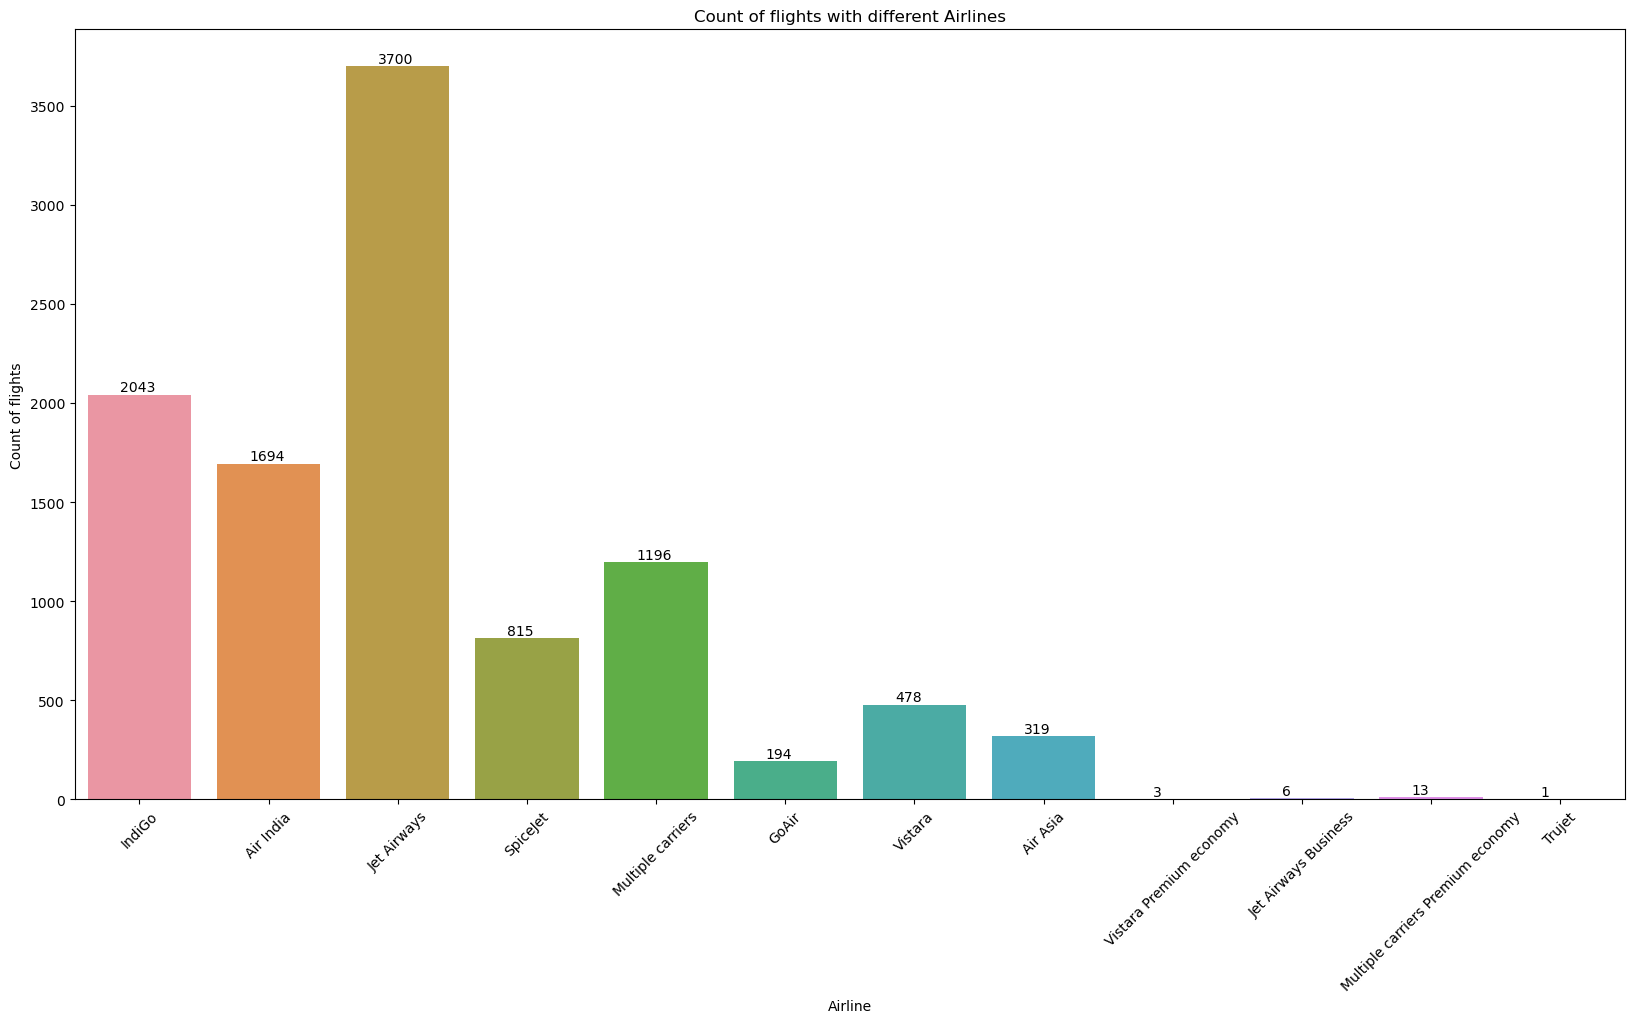

In [25]:
plt.figure(figsize=(20,10))
plt.title('Count of flights with different Airlines')
ax=sns.countplot(x = 'Airline', data =data)
plt.xlabel('Airline')
plt.ylabel('Count of flights')
plt.xticks(rotation = 45)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+0.25, p.get_height()+1), va='bottom', color= 'black')

* Jet Airways has the highest number of flights, indicating a strong presence and market share. 
* IndiGo follows Jet Airways in the number of flights, suggesting it is also a significant competitor in the market.
* Air India is another key player, although with fewer flights compared to Jet Airways and IndiGo. 
* Multiple carriers category indicates flights operated by more than one airline, which could involve agreements or partnerships.
* premium options like Jet Airways Business and Vistara Premium Economy have significantly fewer flights. These could cater to niche markets or offer      specialized services.
* The presence of low-cost carriers like SpiceJet, Air Asia, and GoAir reflects the demand for budget travel options, which likely attracts price-         sensitive customers.

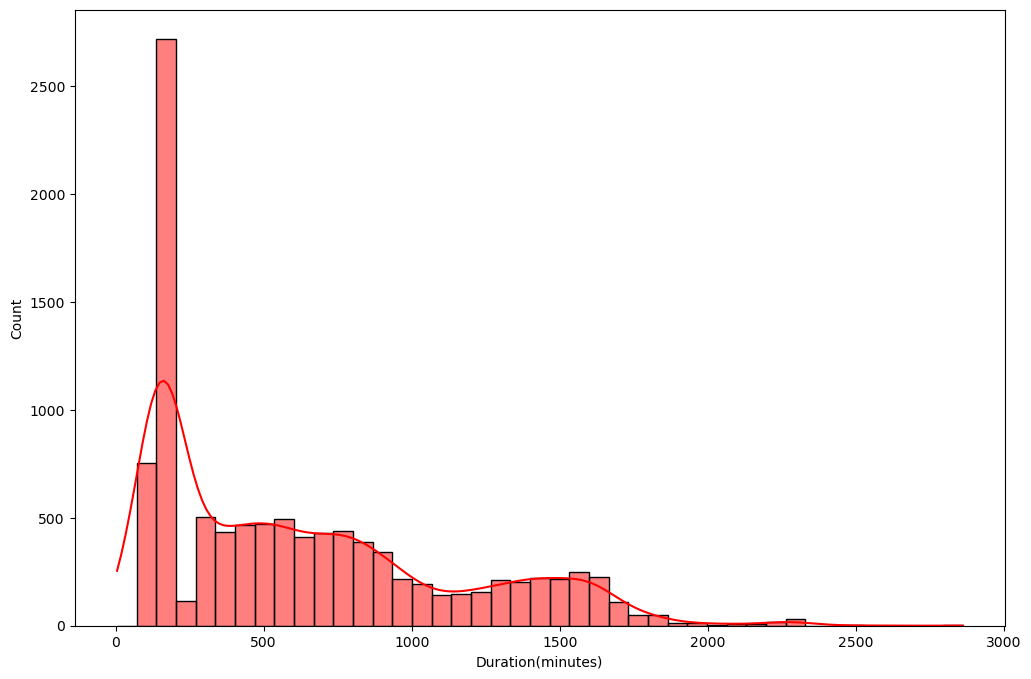

In [26]:
plt.figure(figsize=(12,8))
sns.histplot(data["Duration"], kde=True,color='red')
plt.xlabel("Duration(minutes)")
plt.show()

* The histogram shows a right-skewed distribution, meaning most flights have shorter durations while a few have significantly longer durations.
* The peak of this histogram represents the most common flight durations.

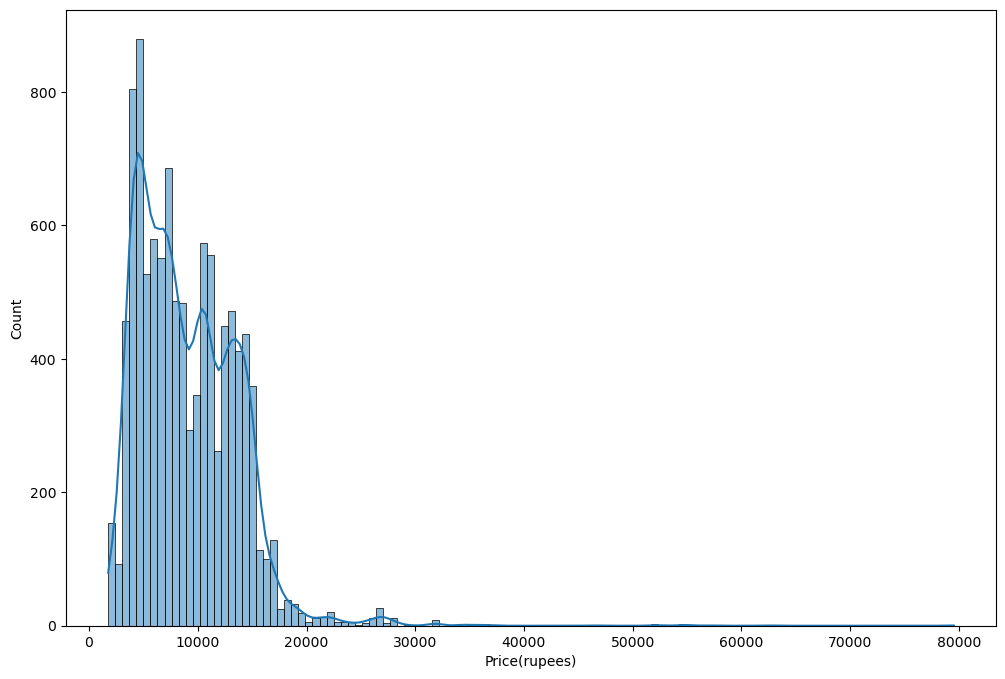

In [27]:
plt.figure(figsize=(12,8))
sns.histplot(data["Price"], kde=True,palette='pastel')
plt.xlabel("Price(rupees)")
plt.show()

* The histogram shows right-skewed, indicating that most flights have lower prices, with fewer flights having much higher prices. This shows that budget and economy flights are more prevalent than premium or business class options.

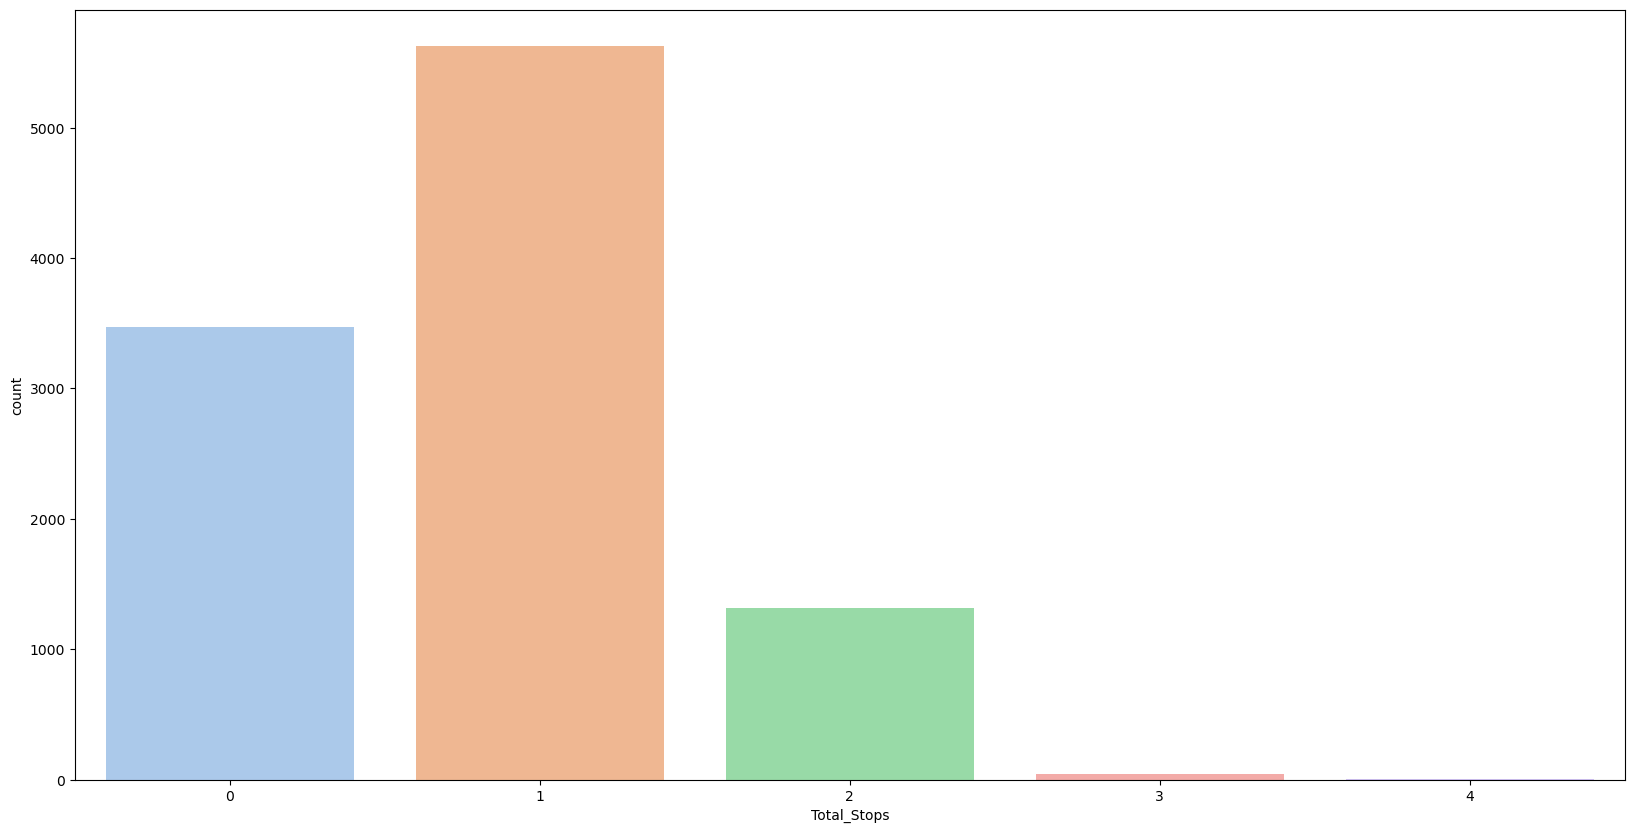

In [28]:
plt.figure(figsize=(20,10))
sns.countplot(x='Total_Stops', data=data, palette="pastel")
plt.show()

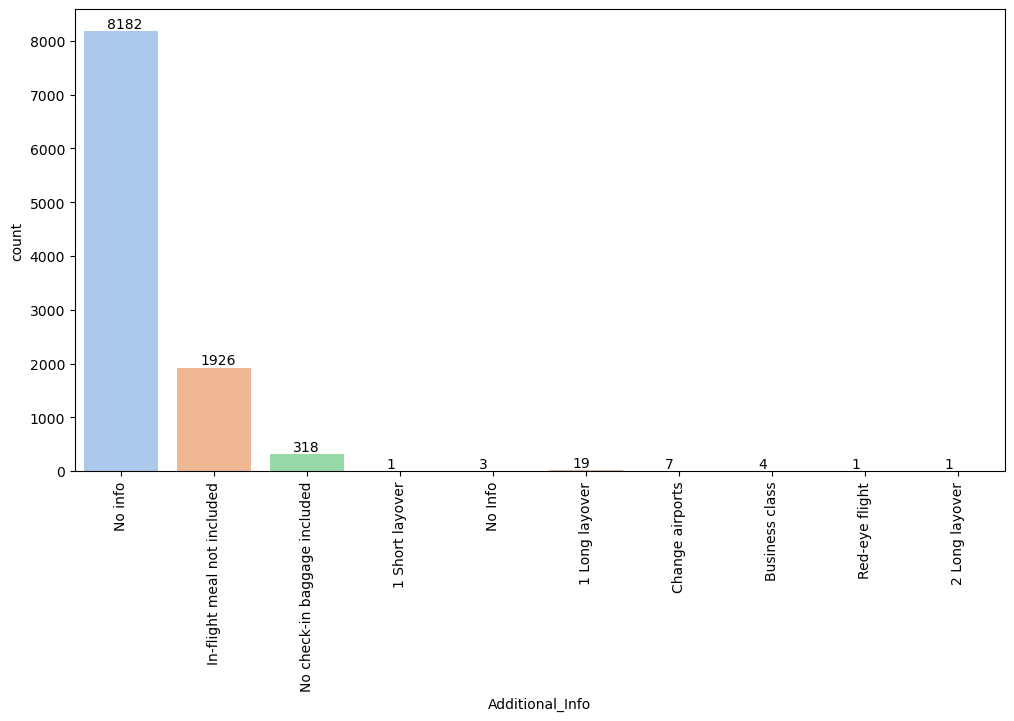

In [29]:
plt.figure(figsize=(12,6))
ax=sns.countplot(x = 'Additional_Info', data =data,palette="pastel")
plt.xticks(rotation=90)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+0.25, p.get_height()+1), va='bottom', color= 'black')

In [30]:
data['Journey_month'].value_counts()

Journey_month
5    3395
6    3311
3    2678
4    1078
Name: count, dtype: int64

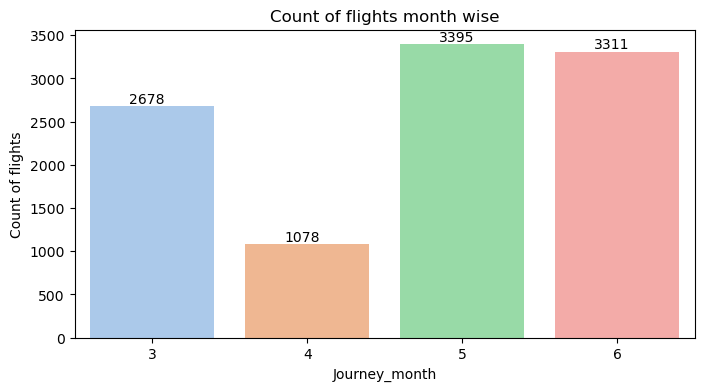

In [31]:
plt.figure(figsize=(8,4))
plt.title('Count of flights month wise')
ax=sns.countplot(x = 'Journey_month', data =data,palette="pastel")
plt.xlabel('Journey_month')
plt.ylabel('Count of flights')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+0.25, p.get_height()+1), va='bottom', color= 'black')

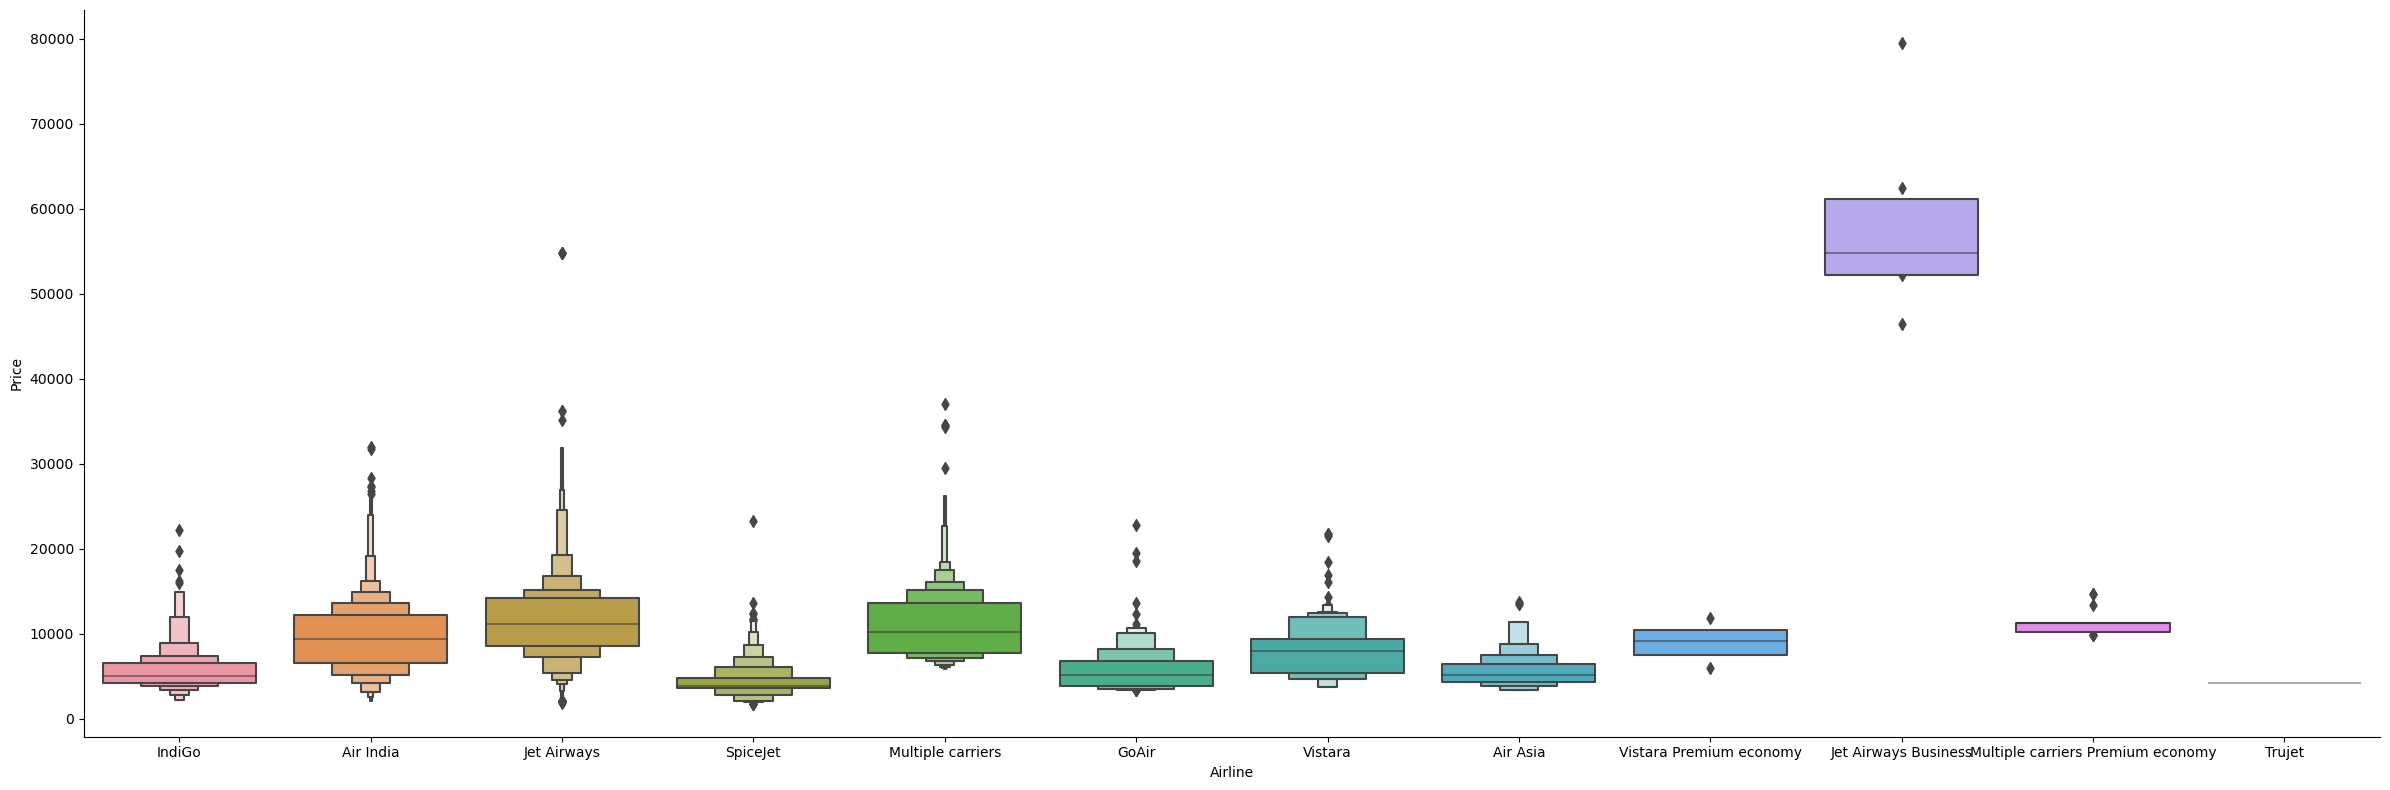

In [32]:
sns.catplot(x='Airline',y='Price', data=data,kind='boxen',height=8,aspect=3)
plt.show()

* The plot shows that premium airlines (e.g:-Jet Airways Business, Vistara Premium Economy) have higher median prices, with the entire distribution of prices being skewed towards the upper end. In contrast, budget airlines (e.g:-IndiGo, SpiceJet, Air Asia) will show a tighter price distribution with lower medians.

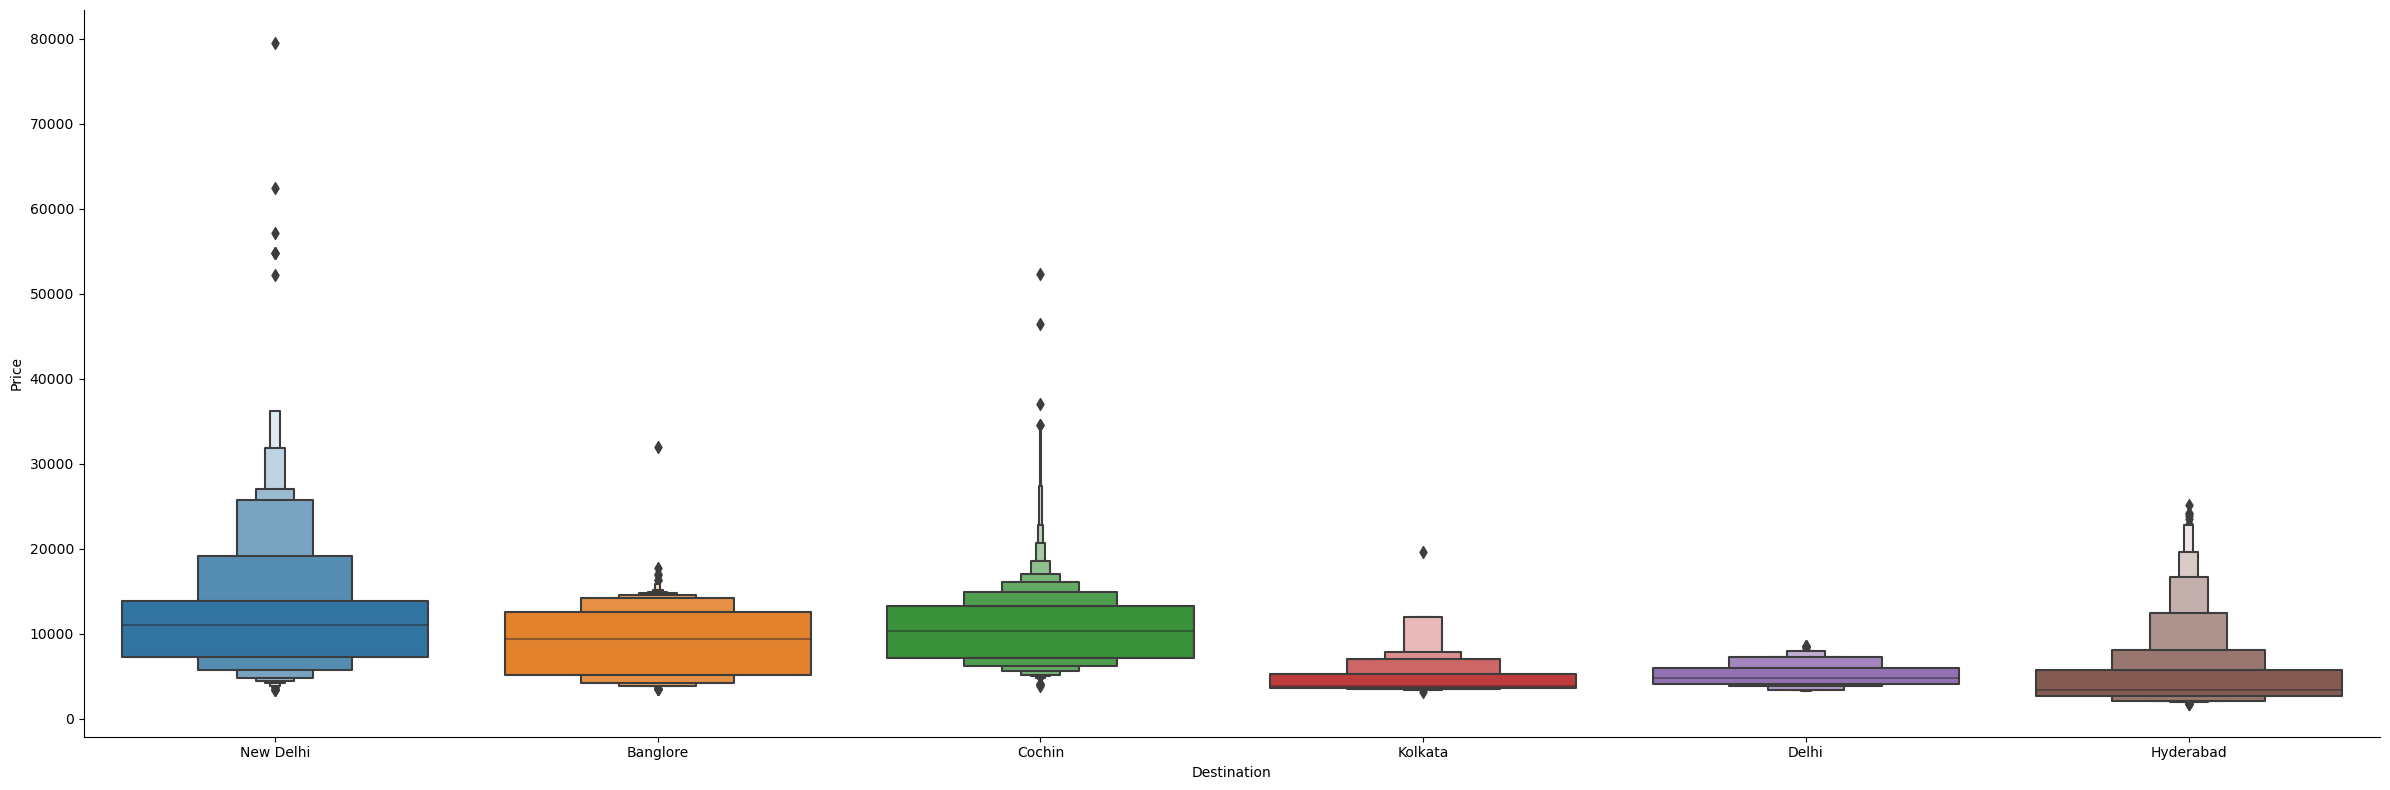

In [33]:
sns.catplot(x='Destination',y='Price', data=data,kind='boxen',height=8,aspect=3)
plt.show()

* A boxen plot shows the distribution of flight prices for each destination. You will likely see variations in the median price and the overall price range for different destinations.
* Destinations that are major travel hubs or popular tourist locations may exhibit higher median prices due to higher demand.

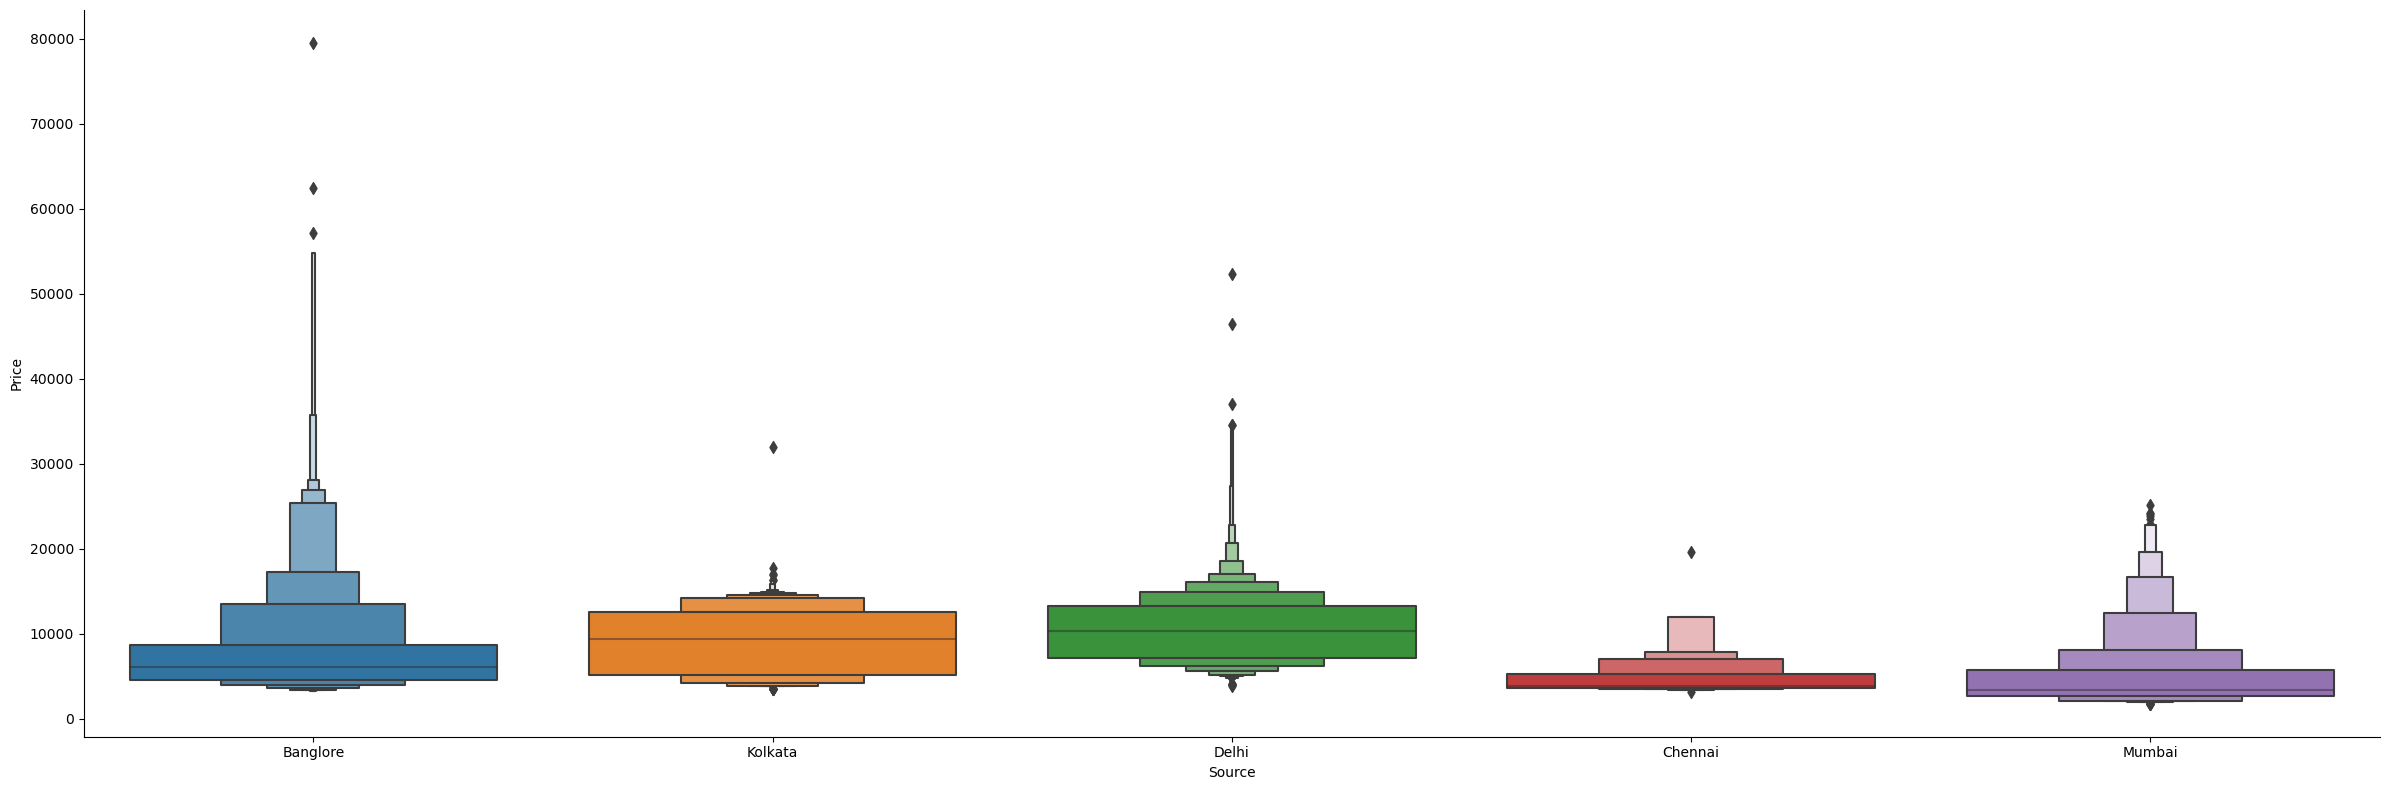

In [34]:
sns.catplot(x='Source',y='Price', data=data,kind='boxen',height=8,aspect=3)
plt.show()

* A boxen plot will show the distribution of flight prices originating from each source location. By analyzing this, we can observe how the starting location affects the cost of flights.
* Sources that are major metropolitan areas or have high passenger traffic may show a higher median price, reflecting the demand and cost of operations in those locations.

## Data Pre-processing and Feature Engineering

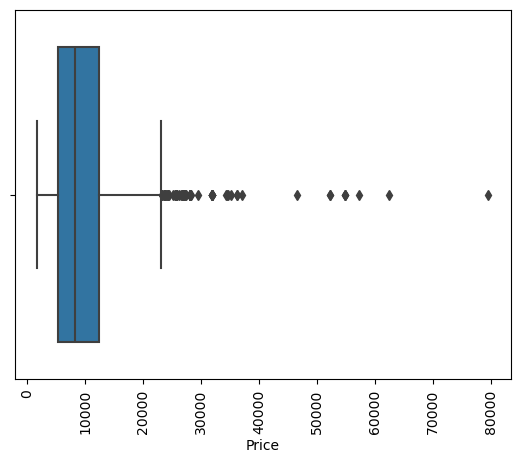

In [35]:
sns.boxplot(x='Price', data=data)
plt.xticks(rotation=90)
plt.show()

In [36]:
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data_clean = data.dropna(subset=['Price'])

In [37]:
Q1=data["Price"].quantile(0.25)
print("lower quartile",Q1)
Q3=data["Price"].quantile(0.75)
print("upper quartile",Q3)

lower quartile 5224.0
upper quartile 12344.75


In [38]:
IQR=Q3-Q1
IQR

7120.75

In [39]:
lower_limit=Q1-1.5*IQR
print("lower_limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit is",upper_limit)

lower_limit is -5457.125
upper_limit is 23025.875


In [40]:
data.loc[data['Price']>upper_limit]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
123,Air India,Delhi,Cochin,DEL → BOM → COK,1215,1,No info,27430,1,3,23,0,19,15
396,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,385,1,No info,36983,1,3,12,50,19,15
486,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,380,1,No info,26890,1,3,8,55,15,15
510,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,325,1,No info,26890,1,3,7,0,12,25
597,Air India,Mumbai,Hyderabad,BOM → JDH → DEL → HYD,1775,2,No info,25139,6,3,9,40,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10353,Jet Airways,Mumbai,Hyderabad,BOM → BDQ → DEL → HYD,1260,2,No info,24210,6,3,19,50,16,50
10364,Jet Airways Business,Banglore,New Delhi,BLR → MAA → DEL,280,1,Business class,57209,1,3,9,45,14,25
10383,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,1325,1,No info,26890,1,3,7,0,5,5
10439,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,860,1,No info,31825,1,3,18,40,9,0


In [41]:
data.loc[data['Price']>upper_limit,"Price"]=data['Price'].median()

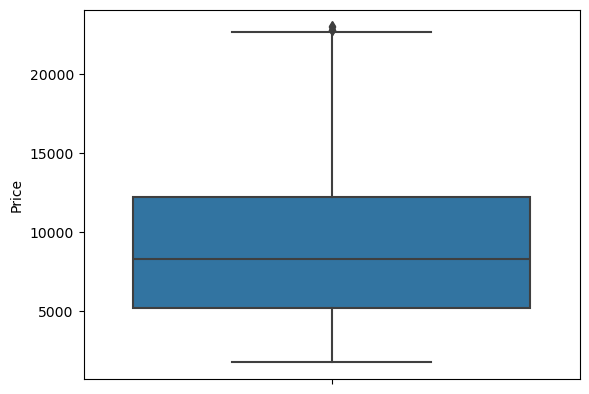

In [42]:
sns.boxplot(y=data['Price'])
plt.show()

In [43]:
from sklearn.preprocessing import LabelEncoder 

In [44]:
le_Airline=LabelEncoder()
le_Source=LabelEncoder()
le_Destination=LabelEncoder()

In [45]:
data["Airline"]=le_Airline.fit_transform(data["Airline"])
data["Source"]=le_Source.fit_transform(data["Source"])
data["Destination"]=le_Destination.fit_transform(data["Destination"])

In [46]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,3,0,5,BLR → DEL,170,0,No info,3897,24,3,22,20,1,10
1,1,3,0,CCU → IXR → BBI → BLR,445,2,No info,7662,1,5,5,50,13,15
2,4,2,1,DEL → LKO → BOM → COK,1140,2,No info,13882,9,6,9,25,4,25
3,3,3,0,CCU → NAG → BLR,325,1,No info,6218,12,5,18,5,23,30
4,3,0,5,BLR → NAG → DEL,285,1,No info,13302,1,3,16,50,21,35


In [47]:
print("Airline mapping:", dict(zip(le_Airline.classes_, le_Airline.transform(le_Airline.classes_))))

Airline mapping: {'Air Asia': 0, 'Air India': 1, 'GoAir': 2, 'IndiGo': 3, 'Jet Airways': 4, 'Jet Airways Business': 5, 'Multiple carriers': 6, 'Multiple carriers Premium economy': 7, 'SpiceJet': 8, 'Trujet': 9, 'Vistara': 10, 'Vistara Premium economy': 11}


In [48]:
print("Source mapping:", dict(zip(le_Source.classes_, le_Source.transform(le_Source.classes_))))
print("Destination mapping:", dict(zip(le_Destination.classes_, le_Destination.transform(le_Destination.classes_))))

Source mapping: {'Banglore': 0, 'Chennai': 1, 'Delhi': 2, 'Kolkata': 3, 'Mumbai': 4}
Destination mapping: {'Banglore': 0, 'Cochin': 1, 'Delhi': 2, 'Hyderabad': 3, 'Kolkata': 4, 'New Delhi': 5}


In [50]:
data['Additional_Info'].replace({"No info": 'No Info'}, inplace = True)  #‘ No Info’ values are repeated

In [51]:
le_Additional_Info=LabelEncoder()
data["Additional_Info"]=le_Additional_Info.fit_transform(data["Additional_Info"])

In [52]:
print("Additional Info mapping:", dict(zip(le_Additional_Info.classes_, le_Additional_Info.transform(le_Additional_Info.classes_))))

Additional Info mapping: {'1 Long layover': 0, '1 Short layover': 1, '2 Long layover': 2, 'Business class': 3, 'Change airports': 4, 'In-flight meal not included': 5, 'No Info': 6, 'No check-in baggage included': 7, 'Red-eye flight': 8}


In [53]:
data.drop(["Route"], axis = 1, inplace = True) 

In [54]:
data.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,3,0,5,170,0,6,3897,24,3,22,20,1,10
1,1,3,0,445,2,6,7662,1,5,5,50,13,15
2,4,2,1,1140,2,6,13882,9,6,9,25,4,25
3,3,3,0,325,1,6,6218,12,5,18,5,23,30
4,3,0,5,285,1,6,13302,1,3,16,50,21,35


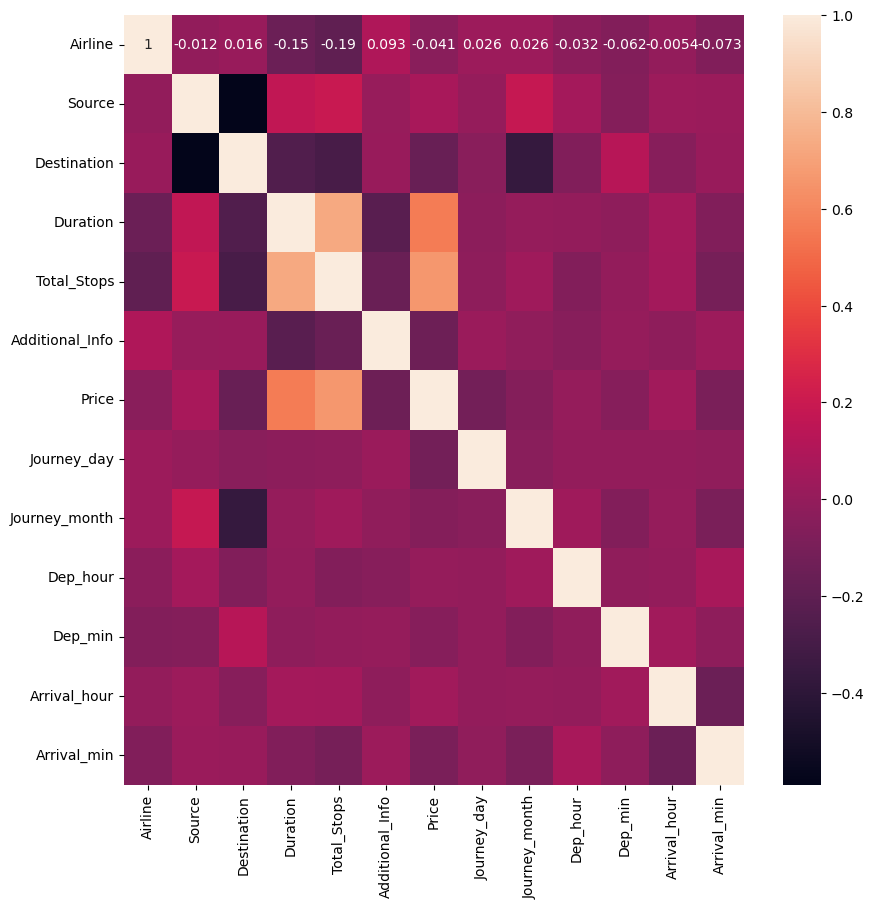

In [55]:
plt.figure(figsize = (10,10))
sns.heatmap(data.corr(), annot = True)
plt.show()

## Task 2:-Create a predictive model which will help the customers to predict future flight prices and plan their journey accordingly.

## Model Creation and Evaluation

In [56]:
x=data.drop('Price',axis=1)
y=data['Price']

In [57]:
x.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,3,0,5,170,0,6,24,3,22,20,1,10
1,1,3,0,445,2,6,1,5,5,50,13,15


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=32)

In [59]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

## Linear Regression

* Linear Regression is suitable as a baseline model for the flight fare prediction task. While it may not capture complex, non-linear relationships        between features it provides a good starting point for understanding the data's structure.
* For Linear Regression, hyperparameter tuning is limited because the model doesn't have many hyperparameters.
* While it's a good starting point, more complex models might be necessary to capture non-linear relationships in the data.

In [60]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(x_train_sc,y_train)
y_predict=LR.predict(x_test_sc)
y_pre_train=LR.predict(x_train_sc)

In [61]:
y_test
y_predict

array([11182.53673117,  5476.26231842, 12603.07448638, ...,
       10374.50826683,  9163.02881609,  8589.63279316])

In [62]:
y_train
y_pre_train

array([10793.93107386, 12707.22792719,  9989.98319704, ...,
        5543.16904382, 15282.40702697,  9853.88734187])

In [63]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import math

In [64]:
## Test Model
mae_lr=mean_absolute_error(y_test,y_predict)
mse_lr=mean_squared_error(y_test,y_predict)
rmse_lr=np.sqrt(mse_lr)## R<SE
r2_lr=r2_score(y_test,y_predict)

print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression MSE: {mse_lr}")
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression r2_score: {r2_lr}")

Linear Regression MAE: 2258.9878152595065
Linear Regression MSE: 8430938.65010239
Linear Regression RMSE: 2903.6078678262306
Linear Regression r2_score: 0.47637120791043097


In [65]:
# Train Model

mae_lr=mean_absolute_error(y_train,y_pre_train)
mse_lr=mean_squared_error(y_train,y_pre_train)
rmse_lr=np.sqrt(mse_lr)   ## R<SE
r2_lr=r2_score(y_train,y_pre_train)

print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression MSE: {mse_lr}")
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression r2_score: {r2_lr}")

Linear Regression MAE: 2272.081953919058
Linear Regression MSE: 8343567.410720343
Linear Regression RMSE: 2888.5233962563543
Linear Regression r2_score: 0.4956274648634139


In [66]:
x_test.shape

(3139, 12)

In [67]:
x_train.shape

(7323, 12)

In [68]:
##adjusted r2_score of test data
ad_test=1-(1-0.47)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.49)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.4679654510556621
Adjusted R2_Score of Train Data: 0.48916279069767443


## Ridge Regressor


* Ridge regression adds an L2 penalty to the loss function to prevent overfitting.
* Ridge regression is useful when you suspect multicollinearity among features.
* Scaling is important for Ridge regression due to the regularization term.

In [69]:
from sklearn.linear_model import Ridge
R=Ridge()
R.fit(x_train_sc,y_train)
y_predict=R.predict(x_test_sc)
y_pre_train=R.predict(x_train_sc)

In [70]:
## Test Model
mae_R=mean_absolute_error(y_test,y_predict)
mse_R=mean_squared_error(y_test,y_predict)
rmse_R=np.sqrt(mse_R)## R<SE
r2_R=r2_score(y_test,y_predict)

print(f"Ridge Regression Test Model:")
print(f"Ridge Regression MAE: {mae_R}")
print(f"Ridge Regression MSE: {mse_R}")
print(f"Ridge Regression RMSE: {rmse_R}")
print(f"Ridge Regression r2_score: {r2_R}")

Ridge Regression Test Model:
Ridge Regression MAE: 2258.991566468684
Ridge Regression MSE: 8430926.443022253
Ridge Regression RMSE: 2903.6057657716296
Ridge Regression r2_score: 0.47637196606784293


In [71]:
## Train Model
mae_R=mean_absolute_error(y_train,y_pre_train)
mse_R=mean_squared_error(y_train,y_pre_train)
rmse_R=np.sqrt(mse_R)## R<SE
r2_R=r2_score(y_train,y_pre_train)

print(f"Ridge Regression Train Model:")
print(f"Ridge Regression MAE: {mae_R}")
print(f"Ridge Regression MSE: {mse_R}")
print(f"Ridge Regression RMSE: {rmse_R}")
print(f"Ridge Regression r2_score: {r2_R}")

Ridge Regression Train Model:
Ridge Regression MAE: 2272.091289811656
Ridge Regression MSE: 8343567.587601335
Ridge Regression RMSE: 2888.5234268742456
Ridge Regression r2_score: 0.4956274541708756


In [72]:
from sklearn.model_selection import GridSearchCV

params = {
    'alpha':[0.1,1,10,100,200,500]   # Range of alpha values to test
}

#GridSearchCV exhaustively tries every combination of hyperparameters specified in the grid.
Ridge_R=GridSearchCV(R,params,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
Ridge_R.fit(x_train,y_train)
best_params=Ridge_R.best_params_
print(f"Best paramters: {best_params})")

Best paramters: {'alpha': 1})


In [73]:
Bestparamters: ({'alpha': 1})

In [74]:
R1=Ridge(alpha=1)

In [75]:
R1.fit(x_train_sc,y_train)
y_predict=R1.predict(x_test_sc)
y_pre_train=R1.predict(x_train_sc)

In [76]:
## Test Model
mae_R1=mean_absolute_error(y_test,y_predict)
mse_R1=mean_squared_error(y_test,y_predict)
rmse_R1=np.sqrt(mse_R1)
r2_R1=r2_score(y_test,y_predict)

print(f"Ridge Regression Test Model after Hyperparameter Tuning:")
print(f"Ridge Regression MAE: {mae_R1}")
print(f"Ridge Regression MSE: {mse_R1}")
print(f"Ridge Regression RMSE: {rmse_R1}")
print(f"Ridge Regression r2_score: {r2_R1}")

Ridge Regression Test Model after Hyperparameter Tuning:
Ridge Regression MAE: 2258.991566468684
Ridge Regression MSE: 8430926.443022253
Ridge Regression RMSE: 2903.6057657716296
Ridge Regression r2_score: 0.47637196606784293


In [77]:
## Train Model
mae_R1=mean_absolute_error(y_train,y_pre_train)
mse_R1=mean_squared_error(y_train,y_pre_train)
rmse_R1=np.sqrt(mse_R1)## R<SE
r2_R1=r2_score(y_train,y_pre_train)

print(f"Ridge Regression Train Model after Hyperparameter Tuning:")
print(f"Ridge Regression MAE: {mae_R1}")
print(f"Ridge Regression MSE: {mse_R1}")
print(f"Ridge Regression RMSE: {rmse_R1}")
print(f"Ridge Regression r2_score: {r2_R1}")

Ridge Regression Train Model after Hyperparameter Tuning:
Ridge Regression MAE: 2272.091289811656
Ridge Regression MSE: 8343567.587601335
Ridge Regression RMSE: 2888.5234268742456
Ridge Regression r2_score: 0.4956274541708756


In [78]:
##adjusted r2_score of test data
ad_test=1-(1-0.47)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.49)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.4679654510556621
Adjusted R2_Score of Train Data: 0.48916279069767443


## DecisionTree Regressor

Given the potentially complex relationships between features like date, source, destination, and airline type with the flight fare, Decision Tree Regressor can be a powerful model. It can capture non-linear patterns and interactions between features that simpler models might miss.
* Performance: Decision Tree Regressor can capture complex patterns but is prone to overfitting, especially if the tree grows too deep.
* If overfitting is observed, consider using ensemble methods like Random Forest or Gradient Boosting, which can provide more stable and accurate          predictions by combining multiple trees.

In [79]:
from sklearn.tree import DecisionTreeRegressor
DT=DecisionTreeRegressor()
DT.fit(x_train_sc,y_train)
y_predict=DT.predict(x_test_sc)
y_pre_train=DT.predict(x_train_sc)

In [80]:
## Test Model
mae_dt=mean_absolute_error(y_test,y_predict)
mse_dt=mean_squared_error(y_test,y_predict)
rmse_dt=np.sqrt(mse_dt)## R<SE
r2_dt=r2_score(y_test,y_predict)

print(f"DecisionTree Regressor Test Model: ")
print(f"DecisionTree Regressor MAE: {mae_dt}")
print(f"DecisionTree Regressor MSE: {mse_dt}")
print(f"DecisionTree Regressor RMSE: {rmse_dt}")
print(f"DecisionTree Regressor r2_score: {r2_dt}")

DecisionTree Regressor Test Model: 
DecisionTree Regressor MAE: 803.7222576191995
DecisionTree Regressor MSE: 3129373.710054511
DecisionTree Regressor RMSE: 1769.0035924368585
DecisionTree Regressor r2_score: 0.8056408374205408


In [81]:
mae_dt=mean_absolute_error(y_train,y_pre_train)
mse_dt=mean_squared_error(y_train,y_pre_train)
rmse_dt=np.sqrt(mse_dt)## R<SE
r2_dt=r2_score(y_train,y_pre_train)

print(f"DecisionTree Regressor Train Model: ")
print(f"DecisionTree Regressor MAE: {mae_dt}")
print(f"DecisionTree Regressor MSE: {mse_dt}")
print(f"DecisionTree Regressor RMSE: {rmse_dt}")
print(f"DecisionTree Regressor r2_score: {r2_dt}")

DecisionTree Regressor Train Model: 
DecisionTree Regressor MAE: 37.85980244890527
DecisionTree Regressor MSE: 82782.51995994356
DecisionTree Regressor RMSE: 287.719516126285
DecisionTree Regressor r2_score: 0.9949957581209754


In [84]:
params={
     "criterion":("squared_error", "friedman_mse"), #quality of split
    "splitter":("best", "random"), # searches the features for a split
    "max_depth":[None, 5, 10, 15, 20], #depth of tree range from 1 to 19
    "min_samples_split":[2, 5, 10, 15],    #the minimum number of samples required to split internal node
    "min_samples_leaf":[1, 2, 4, 6], #minimum number of samples required to be at a leaf node,we are passing list which is range from 1 to 19
    "max_features":(None,"sqrt","log2",0.5,0.8), #it controls the number of features that the model considers when looking for the best split at each node
    "max_leaf_nodes":[None,10,20,30,50,100] # it specifies the maximum number of leaf nodes that the tree can have
}
#passing model to gridsearchCV ,
tree_R=GridSearchCV(DT,params,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
tree_R.fit(x_train,y_train)
best_params=tree_R.best_params_
print(f"Best paramters: {best_params})")

Best paramters: {'criterion': 'squared_error', 'max_depth': 20, 'max_features': 0.8, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 15, 'splitter': 'best'})


In [85]:
Bestparamters: ({'criterion': 'squared_error', 'max_depth': 20, 'max_features': 0.8, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 15, 'splitter': 'best'})

In [86]:
DT1=DecisionTreeRegressor(criterion='squared_error',max_depth=20,max_features=0.8,max_leaf_nodes=None,min_samples_leaf=2,min_samples_split=15,splitter='best')

In [87]:
DT1.fit(x_train_sc,y_train)
y_predict=DT1.predict(x_test_sc)
y_pre_train=DT1.predict(x_train_sc)

In [88]:
## Test Model
mae_dt1=mean_absolute_error(y_test,y_predict)
mse_dt1=mean_squared_error(y_test,y_predict)
rmse_dt1=np.sqrt(mse_dt1)## R<SE
r2_dt1=r2_score(y_test,y_predict)

print(f"DecisionTree Regressor Test Model after Hyperparameter Tuning:")
print(f"DecisionTree Regressor MAE: {mae_dt1}")
print(f"DecisionTree Regressor MSE: {mse_dt1}")
print(f"DecisionTree Regressor RMSE: {rmse_dt1}")
print(f"DecisionTree Regressor r2_score: {r2_dt1}")

DecisionTree Regressor Test Model after Hyperparameter Tuning:
DecisionTree Regressor MAE: 888.6641948278617
DecisionTree Regressor MSE: 2753738.823232654
DecisionTree Regressor RMSE: 1659.4393098973683
DecisionTree Regressor r2_score: 0.8289707713954301


In [89]:
# Train Model
mae_dt1=mean_absolute_error(y_train,y_pre_train)
mse_dt1=mean_squared_error(y_train,y_pre_train)
rmse_dt1=np.sqrt(mse_dt1)## R<SE
r2_dt1=r2_score(y_train,y_pre_train)

print(f"DecisionTree Regressor Train Model after Hyperparameter Tuning:")
print(f"DecisionTree Regressor MAE: {mae_dt1}")
print(f"DecisionTree Regressor MSE: {mse_dt1}")
print(f"DecisionTree Regressor RMSE: {rmse_dt1}")
print(f"DecisionTree Regressor r2_score: {r2_dt1}")

DecisionTree Regressor Train Model after Hyperparameter Tuning:
DecisionTree Regressor MAE: 578.839018626237
DecisionTree Regressor MSE: 1132250.2680526404
DecisionTree Regressor RMSE: 1064.0724919161478
DecisionTree Regressor r2_score: 0.9315549440670864


In [90]:
##adjusted r2_score of test data
ad_test=1-(1-0.82)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.93)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8193090211132437
Adjusted R2_Score of Train Data: 0.9298850889192887


# RandomForestRegressor

* Random Forest Regressor is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and           stable prediction.
* Random Forest is well-suited for the flight fare prediction task because it can capture complex interactions between features and is robust to           outliers and non-linearities in the data. 
* Performance: Random Forest Regressor typically performs well on complex datasets with non-linear relationships, like the flight fare dataset. It         balances the model's variance and bias, leading to better generalization on unseen data.
* This model is robust to overfitting, especially compared to individual decision trees, making it suitable for large and diverse datasets.

In [91]:
from sklearn.ensemble import RandomForestRegressor
RF=RandomForestRegressor()
RF.fit(x_train_sc,y_train)
y_predict=RF.predict(x_test_sc)
y_pre_train=RF.predict(x_train_sc)

In [92]:
## Test Model
mae_rf=mean_absolute_error(y_test,y_predict)
mse_rf=mean_squared_error(y_test,y_predict)
rmse_rf=np.sqrt(mse_rf)## R<SE
r2_rf=r2_score(y_test,y_predict)

print(f"RandomForest Regressor Test Model: ")
print(f"RandomForest Regressor MAE: {mae_rf}")
print(f"RandomForest Regressor MSE: {mse_rf}")
print(f"RandomForest Regressor RMSE: {rmse_rf}")
print(f"RandomForest Regressor r2_score: {r2_rf}")

RandomForest Regressor Test Model: 
RandomForest Regressor MAE: 708.9303893578987
RandomForest Regressor MSE: 1902522.1310901793
RandomForest Regressor RMSE: 1379.319444903964
RandomForest Regressor r2_score: 0.8818381432043365


In [93]:
## Train Model
mae_rf=mean_absolute_error(y_train,y_pre_train)
mse_rf=mean_squared_error(y_train,y_pre_train)
rmse_rf=np.sqrt(mse_rf)## R<SE
r2_rf=r2_score(y_train,y_pre_train)

print(f"RandomForest Regressor Train Model: ")
print(f"RandomForest Regressor MAE: {mae_rf}")
print(f"RandomForest Regressor MSE: {mse_rf}")
print(f"RandomForest Regressor RMSE: {rmse_rf}")
print(f"RandomForest Regressor r2_score: {r2_rf}")

RandomForest Regressor Train Model: 
RandomForest Regressor MAE: 268.58880576255723
RandomForest Regressor MSE: 304847.5858596505
RandomForest Regressor RMSE: 552.130044337066
RandomForest Regressor r2_score: 0.9815718214833689


In [94]:
from sklearn.model_selection import RandomizedSearchCV
params={
    'n_estimators': [100,200,500], # represents the number of trees in the forest
    'max_depth':[None,10,20,30],   #sets the maximum depth of each tree
    'min_samples_split':[2,5,10],  #minimum number of samples required to split an internal node
    'min_samples_leaf':[1,2,4],    #minimum number of samples required to be at a leaf node.
    'bootstrap':[True,False]       #decides whether bootstrap samples are used when building trees
} 

forest_R=RandomizedSearchCV(RF,params,n_iter=10,cv=5,random_state=32,scoring="neg_mean_squared_error",n_jobs=-1)
forest_R.fit(x_train,y_train)
best_params=forest_R.best_params_
print(f"Best paramters: {best_params})")

Best paramters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True})


In [95]:
Bestparamters: ({'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True})

In [96]:
RF1=RandomForestRegressor(n_estimators=500,min_samples_split=2,min_samples_leaf=4,max_depth=30,bootstrap=True)

In [97]:
RF1.fit(x_train_sc,y_train)
y_predict=RF1.predict(x_test_sc)
y_pre_train=RF1.predict(x_train_sc)

In [98]:
## Test Model
mae_rf1=mean_absolute_error(y_test,y_predict)
mse_rf1=mean_squared_error(y_test,y_predict)
rmse_rf1=np.sqrt(mse_rf1)## R<SE
r2_rf1=r2_score(y_test,y_predict)

print(f"RandomForest Regressor Test Model after Hyperparameter Tuning:")
print(f"RandomForest Regressor MAE: {mae_rf1}")
print(f"RandomForest Regressor MSE: {mse_rf1}")
print(f"RandomForest Regressor RMSE: {rmse_rf1}")
print(f"RandomForest Regressor r2_score: {r2_rf1}")

RandomForest Regressor Test Model after Hyperparameter Tuning:
RandomForest Regressor MAE: 779.2163008720789
RandomForest Regressor MSE: 2102071.406673915
RandomForest Regressor RMSE: 1449.852201665368
RandomForest Regressor r2_score: 0.8694445355085918


In [99]:
# Train Model
mae_rf1=mean_absolute_error(y_train,y_pre_train)
mse_rf1=mean_squared_error(y_train,y_pre_train)
rmse_rf1=np.sqrt(mse_rf1)## R<SE
r2_rf1=r2_score(y_train,y_pre_train)

print(f"RandomForest Regressor Train Model after Hyperparameter Tuning:")
print(f"RandomForest Regressor MAE: {mae_rf1}")
print(f"RandomForest Regressor MSE: {mse_rf1}")
print(f"RandomForest Regressor RMSE: {rmse_rf1}")
print(f"RandomForest Regressor r2_score: {r2_rf1}")

RandomForest Regressor Train Model after Hyperparameter Tuning:
RandomForest Regressor MAE: 535.5898078073458
RandomForest Regressor MSE: 988039.531844921
RandomForest Regressor RMSE: 994.0017765803645
RandomForest Regressor r2_score: 0.940272550222164


In [100]:
##adjusted r2_score of test data
ad_test=1-(1-0.86)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.94)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8594625719769673
Adjusted R2_Score of Train Data: 0.9399015047879616


## GradientBoosting Regressor

* Gradient Boosting Regressor is an ensemble technique that builds models sequentially, with each new model attempting to correct the errors made by       the previous models.
* Gradient Boosting is well-suited for predicting flight fares due to its ability to capture complex patterns and relationships within the data. It        can handle non-linear interactions between features and target variables.
* Performance: Gradient Boosting Regressor is highly effective for complex datasets with non-linear relationships.
* While powerful, Gradient Boosting is prone to overfitting if not carefully tuned. 

In [101]:
from sklearn.ensemble import GradientBoostingRegressor
GB=GradientBoostingRegressor()
GB.fit(x_train_sc,y_train)
y_predict=GB.predict(x_test_sc)
y_pre_train=GB.predict(x_train_sc)

In [102]:
## Test Model
mae_gb=mean_absolute_error(y_test,y_predict)
mse_gb=mean_squared_error(y_test,y_predict)
rmse_gb=np.sqrt(mse_gb)
r2_gb=r2_score(y_test,y_predict)

print(f"GradientBoosting Regressor Test Model:")
print(f"GradientBoosting Regressor MAE: {mae_gb}")
print(f"GradientBoosting Regressor MSE: {mse_gb}")
print(f"GradientBoosting Regressor RMSE: {rmse_gb}")
print(f"GradientBoosting Regressor r2_score: {r2_gb}")

GradientBoosting Regressor Test Model:
GradientBoosting Regressor MAE: 1257.3619601045548
GradientBoosting Regressor MSE: 3328138.7888052734
GradientBoosting Regressor RMSE: 1824.3187190853669
GradientBoosting Regressor r2_score: 0.7932959346267593


In [103]:
## Train Model
mae_gb=mean_absolute_error(y_train,y_pre_train)
mse_gb=mean_squared_error(y_train,y_pre_train)
rmse_gb=np.sqrt(mse_gb)
r2_gb=r2_score(y_train,y_pre_train)

print(f"GradientBoosting Regressor Train Model:")
print(f"GradientBoosting Regressor MAE: {mae_gb}")
print(f"GradientBoosting Regressor MSE: {mse_gb}")
print(f"GradientBoosting Regressor RMSE: {rmse_gb}")
print(f"GradientBoosting Regressor r2_score: {r2_gb}")

GradientBoosting Regressor Train Model:
GradientBoosting Regressor MAE: 1220.362156782497
GradientBoosting Regressor MSE: 3006589.955163487
GradientBoosting Regressor RMSE: 1733.9521202050207
GradientBoosting Regressor r2_score: 0.8182502372002673


In [104]:
params={
    'n_estimators':[100,200,500],  # represents the number of trees in the forest
    'learning_rate':[0.01,0.05,0.1,0.2], # the contribution of each tree
    'max_depth': [3,4,5,6],   # sets the maximum depth of each tree
    'min_samples_split':[2,5,10],  # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],   # minimum number of samples required to be at a leaf node.
    'subsample': [0.6,0.8,1.0],     # the fraction of samples to be used for fitting the individual base learners
    'max_features':['auto','sqrt','log2',0.6,0.8,1.0],  # the number of features to consider when looking for the best split
    'loss':['squared_error','absolute_error','huber','quantile']  # the loss function to be optimised
}

#Random Search sets up a grid of hyperparameter values and selects random combinations to train the model and score.
#This allows you to explicitly control the number of parameter combinations that are attempted.
#The number of search iterations is set based on time or resources.
gb_R=RandomizedSearchCV(GB,params,n_iter=50,cv=5,random_state=32,scoring="neg_mean_squared_error",verbose=1,n_jobs=-1)
gb_R.fit(x_train,y_train)
best_params=gb_R.best_params_
print(f"Best paramters: {best_params})")

#scoring--->performance matrix to check performance
#n_iter--->Number of parameter settings that are sampled. n_iter trades off runtime vs quality of the solution.
#cv------> number of flods
#verbose=Controls the verbosity: the higher, the more messages.
#n_jobs---->Number of jobs to run in parallel,-1 means using all processors.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best paramters: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 6, 'loss': 'squared_error', 'learning_rate': 0.05})


In [105]:
Bestparamters: ({'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 6, 'loss': 'squared_error', 'learning_rate': 0.05})

In [106]:
GB1=GradientBoostingRegressor(subsample=0.8,n_estimators=500,min_samples_split=10,min_samples_leaf=4,max_features='log2',max_depth=6,loss='squared_error',learning_rate=0.05)

In [107]:
GB1.fit(x_train_sc,y_train)
y_predict=GB1.predict(x_test_sc)
y_pre_train=GB1.predict(x_train_sc)

In [108]:
## Test Model
mae_gb1=mean_absolute_error(y_test,y_predict)
mse_gb1=mean_squared_error(y_test,y_predict)
rmse_gb1=np.sqrt(mse_gb1)## R<SE
r2_gb1=r2_score(y_test,y_predict)

print(f"GradientBoosting Regressor Test Model after Hyperparameter Tuning:")
print(f"GradientBoosting Regressor MAE: {mae_gb1}")
print(f"GradientBoosting Regressor MSE: {mse_gb1}")
print(f"GradientBoosting Regressor RMSE: {rmse_gb1}")
print(f"GradientBoosting Regressor r2_score: {r2_gb1}")

GradientBoosting Regressor Test Model after Hyperparameter Tuning:
GradientBoosting Regressor MAE: 814.1039171472552
GradientBoosting Regressor MSE: 1836422.827235828
GradientBoosting Regressor RMSE: 1355.1467917667915
GradientBoosting Regressor r2_score: 0.885943439194694


In [109]:
# Train Model
mae_gb1=mean_absolute_error(y_train,y_pre_train)
mse_gb1=mean_squared_error(y_train,y_pre_train)
rmse_gb1=np.sqrt(mse_gb1)## R<SE
r2_gb1=r2_score(y_train,y_pre_train)

print(f"GradientBoosting Regressor Train Model after Hyperparameter Tuning:")
print(f"GradientBoosting Regressor MAE: {mae_gb1}")
print(f"GradientBoosting Regressor MSE: {mse_gb1}")
print(f"GradientBoosting Regressor RMSE: {rmse_gb1}")
print(f"GradientBoosting Regressor r2_score: {r2_gb1}")

GradientBoosting Regressor Train Model after Hyperparameter Tuning:
GradientBoosting Regressor MAE: 580.935518214237
GradientBoosting Regressor MSE: 799518.1277227849
GradientBoosting Regressor RMSE: 894.1577756317869
GradientBoosting Regressor r2_score: 0.9516687568858052


In [110]:
##adjusted r2_score of test data
ad_test=1-(1-0.88)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.95)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8795393474088292
Adjusted R2_Score of Train Data: 0.9499179206566347


## XGBRegressor

* XGBoost Regressor is an advanced implementation of the Gradient Boosting framework. It includes enhancements such as regularization, parallel            processing, and improved handling of missing data.
* XGBoost is particularly well-suited for this dataset due to its ability to handle large datasets with complex patterns and relationships. It is          also very efficient, both in terms of computation and memory usage.
* It often outperforms other models, especially when hyperparameters are well-tuned.
* XGBoost is optimized for speed and performance, making it suitable for large datasets and complex tasks.

In [111]:
from xgboost import XGBRegressor
XGBR=XGBRegressor(random_state=32)
XGBR.fit(x_train_sc,y_train)
y_predict=XGBR.predict(x_test_sc)
y_pre_train=XGBR.predict(x_train_sc)

In [112]:
## Test Model
mae_xgb=mean_absolute_error(y_test,y_predict)
mse_xgb=mean_squared_error(y_test,y_predict)
rmse_xgb=np.sqrt(mse_xgb)
r2_xgb=r2_score(y_test,y_predict)

print(f"XGB Regressor Test Model:")
print(f"XGB Regressor MAE: {mae_xgb}")
print(f"XGB Regressor MSE: {mse_xgb}")
print(f"XGB Regressor RMSE: {rmse_xgb}")
print(f"XGB Regressor r2_score: {r2_xgb}")

XGB Regressor Test Model:
XGB Regressor MAE: 782.0002196410082
XGB Regressor MSE: 1868491.3407115596
XGB Regressor RMSE: 1366.9277013476462
XGB Regressor r2_score: 0.8839517277527893


In [113]:
## Train Model
mae_xgb=mean_absolute_error(y_train,y_pre_train)
mse_xgb=mean_squared_error(y_train,y_pre_train)
rmse_xgb=np.sqrt(mse_xgb)
r2_xgb=r2_score(y_train,y_pre_train)

print(f"XGB Regressor Train Model:")
print(f"XGB Regressor MAE: {mae_xgb}")
print(f"XGB Regressor MSE: {mse_xgb}")
print(f"XGB Regressor RMSE: {rmse_xgb}")
print(f"XGB Regressor r2_score: {r2_xgb}")

XGB Regressor Train Model:
XGB Regressor MAE: 446.5827284826862
XGB Regressor MSE: 471630.3866992536
XGB Regressor RMSE: 686.7535123312101
XGB Regressor r2_score: 0.9714897235106759


In [114]:

params={
    'n_estimators':[100,200,300],   # represents the number of trees in the forest
    'learning_rate':[0.01,0.1,0.2],  # the contribution of each tree
    'max_depth':[3,5,7],            # sets the maximum depth of each tree
    'min_child_weight': [1,3,5],   # minimum sum of instance weights (Hessian) needed in a child node
    'subsample':[0.8,1.0],         # the fraction of samples to be used for fitting the individual base learners
    'colsample_bytree':[0.8,1.0],  # fraction of features used for each tree.
    'gamma':[0,0.1,0.5]     # minimum loss reduction required to make a further partition on a leaf node.
}

xgb_R=GridSearchCV(XGBR,params,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
xgb_R.fit(x_train,y_train)
best_params=xgb_R.best_params_
print(f"Best paramters: {best_params})")


Best paramters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 1.0})


In [115]:
Bestparamters: ({'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 1.0})

In [116]:
XGBR1=XGBRegressor(colsample_bytree=0.8,gamma=0,learning_rate=0.1,max_depth=7,min_child_weight=5,n_estimators=300,subsample=1.0)

In [117]:
XGBR1.fit(x_train_sc,y_train)
y_predict=XGBR1.predict(x_test_sc)
y_pre_train=XGBR1.predict(x_train_sc)

In [118]:
## Test Model
mae_xgb1=mean_absolute_error(y_test,y_predict)
mse_xgb1=mean_squared_error(y_test,y_predict)
rmse_xgb1=np.sqrt(mse_xgb1)
r2_xgb1=r2_score(y_test,y_predict)

print(f"XGB Regressor Test Model after Hyperparameter Tuning:")
print(f"XGB Regressor MAE: {mae_xgb1}")
print(f"XGB Regressor MSE: {mse_xgb1}")
print(f"XGB Regressor RMSE: {rmse_xgb1}")
print(f"XGB Regressor r2_score: {r2_xgb1}")

XGB Regressor Test Model after Hyperparameter Tuning:
XGB Regressor MAE: 725.4857979221836
XGB Regressor MSE: 1691798.598930652
XGB Regressor RMSE: 1300.6915848619349
XGB Regressor r2_score: 0.8949257616996034


In [119]:
## Train Model
mae_xgb1=mean_absolute_error(y_train,y_pre_train)
mse_xgb1=mean_squared_error(y_train,y_pre_train)
rmse_xgb1=np.sqrt(mse_xgb1)
r2_xgb1=r2_score(y_train,y_pre_train)

print(f"XGB Regressor Train Model after Hyperparameter Tuning:")
print(f"XGB Regressor MAE: {mae_xgb1}")
print(f"XGB Regressor MSE: {mse_xgb1}")
print(f"XGB Regressor RMSE: {rmse_xgb1}")
print(f"XGB Regressor r2_score: {r2_xgb1}")

XGB Regressor Train Model after Hyperparameter Tuning:
XGB Regressor MAE: 391.1590785039964
XGB Regressor MSE: 397213.2096362148
XGB Regressor RMSE: 630.248530054783
XGB Regressor r2_score: 0.9759882765162844


In [120]:
##adjusted r2_score of test data
ad_test=1-(1-0.89)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.97)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8895777351247601
Adjusted R2_Score of Train Data: 0.9699507523939809


## LightGBM

* LightGBM can handle large datasets with high dimensionality and complex interactions among features.
* LightGBM is effective for this because it can handle large datasets with high dimensionality and complex interactions among features and it's            ability to deal with categorical features directly and its fast training time.
* Performance: LightGBM is highly efficient and can significantly outperform other models.
* LightGBM is designed for speed and efficiency, making it suitable for real-time predictions and large-scale data.

In [121]:
!pip install lightgbm

In [122]:
from lightgbm import LGBMRegressor
LGBMR=LGBMRegressor(random_state=32)
LGBMR.fit(x_train_sc,y_train)
y_predict=LGBMR.predict(x_test_sc)
y_pre_train=LGBMR.predict(x_train_sc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 7323, number of used features: 12
[LightGBM] [Info] Start training from score 8804.334016


In [123]:
## Test Model
mae_lgbm=mean_absolute_error(y_test,y_predict)
mse_lgbm=mean_squared_error(y_test,y_predict)
rmse_lgbm=np.sqrt(mse_lgbm)
r2_lgbm=r2_score(y_test,y_predict)

print(f"LGBM Regressor Test Model:")
print(f"LGBM Regressor MAE: {mae_lgbm}")
print(f"LGBM Regressor MSE: {mse_lgbm}")
print(f"LGBM Regressor RMSE: {rmse_lgbm}")
print(f"LGBM Regressor r2_score: {r2_lgbm}")

LGBM Regressor Test Model:
LGBM Regressor MAE: 887.8055863220369
LGBM Regressor MSE: 2048703.0958144306
LGBM Regressor RMSE: 1431.3291360880035
LGBM Regressor r2_score: 0.8727591349038648


In [124]:
## Train Model
mae_lgbm=mean_absolute_error(y_train,y_pre_train)
mse_lgbm=mean_squared_error(y_train,y_pre_train)
rmse_lgbm=np.sqrt(mse_lgbm)
r2_lgbm=r2_score(y_train,y_pre_train)

print(f"LGBM Regressor Train Model:")
print(f"LGBM Regressor MAE: {mae_lgbm}")
print(f"LGBM Regressor MSE: {mse_lgbm}")
print(f"LGBM Regressor RMSE: {rmse_lgbm}")
print(f"LGBM Regressor r2_score: {r2_lgbm}")

LGBM Regressor Train Model:
LGBM Regressor MAE: 743.3869969531693
LGBM Regressor MSE: 1267268.411470762
LGBM Regressor RMSE: 1125.7301681445524
LGBM Regressor r2_score: 0.9233930344266447


In [125]:
params={
    'n_estimators':[100,200,300],   # represents the number of trees in the forest
    'learning_rate':[0.01,0.1,0.2],  # the contribution of each tree
    'max_depth':[-1,5,7],  # sets the maximum depth of each tree
    'num_leaves': [20,30,40],  # specifies the maximum no of leaves in one tree
    'min_child_weight': [1,3,5],    # minimum sum of instance weights (Hessian) needed in a child node
    'colsample_bytree':[0.8,1.0],  # fraction of features used for each tree.
    'subsample':[0.8,1.0]         # the fraction of samples to be used for fitting the individual base learners
}

lgbm_R=RandomizedSearchCV(LGBMR,params,n_iter=10,cv=5,scoring="neg_mean_squared_error",n_jobs=-1,random_state=32)
lgbm_R.fit(x_train,y_train)
best_params=lgbm_R.best_params_
print(f"Best Parameters:{best_params})")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 7323, number of used features: 12
[LightGBM] [Info] Start training from score 8804.334016
Best Parameters:{'subsample': 0.8, 'num_leaves': 40, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0})


In [126]:
BestParameters: ({'subsample': 0.8, 'num_leaves': 40, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0})

In [127]:
LGBMR1=LGBMRegressor(subsample=0.8,num_leaves=40,n_estimators=300,min_child_weight=3,max_depth=-1,learning_rate=0.1,colsample_bytree=1.0)

In [128]:
LGBMR1.fit(x_train_sc,y_train)
y_predict=LGBMR1.predict(x_test_sc)
y_pre_train=LGBMR1.predict(x_train_sc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 7323, number of used features: 12
[LightGBM] [Info] Start training from score 8804.334016


In [129]:
## Test Model
mae_lgbm1=mean_absolute_error(y_test,y_predict)
mse_lgbm1=mean_squared_error(y_test,y_predict)
rmse_lgbm1=np.sqrt(mse_lgbm1)
r2_lgbm1=r2_score(y_test,y_predict)

print(f"LGBM Regressor Test Model after Hyperparameter Tuning:")
print(f"LGBM Regressor MAE: {mae_lgbm1}")
print(f"LGBM Regressor MSE: {mse_lgbm1}")
print(f"LGBM Regressor RMSE: {rmse_lgbm1}")
print(f"LGBM Regressor r2_score: {r2_lgbm1}")

LGBM Regressor Test Model after Hyperparameter Tuning:
LGBM Regressor MAE: 750.4428382347916
LGBM Regressor MSE: 1750516.4595885584
LGBM Regressor RMSE: 1323.0708445085465
LGBM Regressor r2_score: 0.8912789124309268


In [130]:
## Train Model
mae_lgbm1=mean_absolute_error(y_train,y_pre_train)
mse_lgbm1=mean_squared_error(y_train,y_pre_train)
rmse_lgbm1=np.sqrt(mse_lgbm1)
r2_lgbm1=r2_score(y_train,y_pre_train)

print(f"LGBM Regressor Train Model after Hyperparameter Tuning:")
print(f"LGBM Regressor MAE: {mae_lgbm1}")
print(f"LGBM Regressor MSE: {mse_lgbm1}")
print(f"LGBM Regressor RMSE: {rmse_lgbm1}")
print(f"LGBM Regressor r2_score: {r2_lgbm1}")

LGBM Regressor Train Model after Hyperparameter Tuning:
LGBM Regressor MAE: 474.8931223424532
LGBM Regressor MSE: 581992.3979752824
LGBM Regressor RMSE: 762.8842625033515
LGBM Regressor r2_score: 0.9648182885392819


In [131]:
##adjusted r2_score of test data
ad_test=1-(1-0.89)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.96)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8895777351247601
Adjusted R2_Score of Train Data: 0.9599343365253078


## Support Vector Regression (SVR)

* Support Vector Regression (SVR) is a type of Support Vector Machine (SVM) used for regression tasks.
* SVR is useful for this due to its ability to capture complex, non-linear relationships between features. However, it is generally more                   computationally expensive compared to other models.
* Performance: SVR can provide highly accurate predictions, especially when the relationships between features and the target variable are complex and     non-linear. However, it can be computationally intensive, especially with large datasets or many features.
* SVR is not as efficient as tree-based models or linear models, especially with large datasets.

In [132]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(x_train_sc,y_train)
y_predict=svr.predict(x_test_sc)
y_pre_train=svr.predict(x_train_sc)

In [133]:
## Test Model
mae_svr=mean_absolute_error(y_test,y_predict)
mse_svr=mean_squared_error(y_test,y_predict)
rmse_svr=np.sqrt(mse_svr)
r2_svr=r2_score(y_test,y_predict)

print(f"Support Vector Regressor Test Model:")
print(f"Support Vector Regressor MAE: {mae_svr}")
print(f"Support Vector Regressor MSE: {mse_svr}")
print(f"Support Vector Regressor RMSE: {rmse_svr}")
print(f"Support Vector Regressor r2_score: {r2_svr}")

Support Vector Regressor Test Model:
Support Vector Regressor MAE: 3213.7385077744166
Support Vector Regressor MSE: 15375525.126617363
Support Vector Regressor RMSE: 3921.1637464683063
Support Vector Regressor r2_score: 0.04505678621019371


In [134]:
## Train Model
mae_svr=mean_absolute_error(y_train,y_pre_train)
mse_svr=mean_squared_error(y_train,y_pre_train)
rmse_svr=np.sqrt(mse_svr)
r2_svr=r2_score(y_train,y_pre_train)

print(f"Support Vector Regressor Train Model:")
print(f"Support Vector Regressor MAE: {mae_svr}")
print(f"Support Vector Regressor MSE: {mse_svr}")
print(f"Support Vector Regressor RMSE: {rmse_svr}")
print(f"Support Vector Regressor r2_score: {r2_svr}")

Support Vector Regressor Train Model:
Support Vector Regressor MAE: 3274.0976728492037
Support Vector Regressor MSE: 15672676.731535112
Support Vector Regressor RMSE: 3958.873164365728
Support Vector Regressor r2_score: 0.052579393641157046


In [135]:
params = {
    'C': [0.1, 1, 10],  # controls the trade-off between smooth decision boundaries and correctly classifying training points.
    'epsilon': [0.01, 0.1, 1],  #defines the width of the epsilon-tube within which no penalty is associated with the training loss function.
    'kernel': ['linear', 'rbf', 'poly']   #  parameter specifies the kernel type to be used in the algorithm.
}
svr_R=GridSearchCV(svr,params,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
svr_R.fit(x_train,y_train)
best_params=svr_R.best_params_
print(f"Best Parameters:{best_params} )")

Best Parameters:{'C': 10, 'epsilon': 0.01, 'kernel': 'linear'} )


In [136]:
BestParameters:({'C': 10, 'epsilon': 0.01, 'kernel': 'linear'} )

In [137]:
svr1=SVR(C=10,epsilon=0.01,kernel='linear')

In [138]:
svr1.fit(x_train_sc,y_train)
y_predict=svr1.predict(x_test_sc)
y_pre_train=svr1.predict(x_train_sc)

In [139]:
## Test Model
mae_svr1=mean_absolute_error(y_test,y_predict)
mse_svr1=mean_squared_error(y_test,y_predict)
rmse_svr1=np.sqrt(mse_svr1)
r2_svr1=r2_score(y_test,y_predict)

print(f"Support Vector Regressor Test Model after Hyperparameter Tuning:")
print(f"Support Vector Regressor MAE: {mae_svr1}")
print(f"Support Vector Regressor MSE: {mse_svr1}")
print(f"Support Vector Regressor RMSE: {rmse_svr1}")
print(f"Support Vector Regressor r2_score: {r2_svr1}")

Support Vector Regressor Test Model after Hyperparameter Tuning:
Support Vector Regressor MAE: 2206.1693604713105
Support Vector Regressor MSE: 9188016.93652359
Support Vector Regressor RMSE: 3031.17418445783
Support Vector Regressor r2_score: 0.42935058481158306


In [140]:
## Train Model
mae_svr1=mean_absolute_error(y_train,y_pre_train)
mse_svr1=mean_squared_error(y_train,y_pre_train)
rmse_svr1=np.sqrt(mse_svr1)
r2_svr1=r2_score(y_train,y_pre_train)

print(f"Support Vector Regressor Train Model after Hyperparameter Tuning:")
print(f"Support Vector Regressor MAE: {mae_svr1}")
print(f"Support Vector Regressor MSE: {mse_svr1}")
print(f"Support Vector Regressor RMSE: {rmse_svr1}")
print(f"Support Vector Regressor r2_score: {r2_svr1}")

Support Vector Regressor Train Model after Hyperparameter Tuning:
Support Vector Regressor MAE: 2206.3407481350932
Support Vector Regressor MSE: 8978761.872781806
Support Vector Regressor RMSE: 2996.4582214310626
Support Vector Regressor r2_score: 0.45722966385529573


In [141]:
##adjusted r2_score of test data
ad_test=1-(1-0.42)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.45)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.4177735124760076
Adjusted R2_Score of Train Data: 0.4490971272229821


## KNeighbors Regressor

* K-Nearest Neighbors(KNN) is a simple, non-parametric method used for both classification and regression tasks.In regression,the KNN algorithm            predicts the target value for a new data point by averaging the values of its K-nearest neighbors in the feature space.
* KNN can be useful for flight fare prediction when the relationship between features is highly non-linear and local in nature. However, it might not      perform well on large datasets due to its computational intensity and sensitivity to irrelevant features.
* KNN is computationally expensive, particularly for large datasets, as it requires storing all the training data and performing a distance                calculation for each prediction.

In [142]:
from sklearn.neighbors import KNeighborsRegressor
KNR=KNeighborsRegressor()
KNR.fit(x_train_sc,y_train)
y_predict=KNR.predict(x_test_sc)
y_pre_train=KNR.predict(x_train_sc)

In [143]:
## Test Model
mae_knr=mean_absolute_error(y_test,y_predict)
mse_knr=mean_squared_error(y_test,y_predict)
rmse_knr=np.sqrt(mse_knr)
r2_knr=r2_score(y_test,y_predict)

print(f"KNeighbors Regressor Test Model:")
print(f"KNeighbors Regressor MAE: {mae_knr}")
print(f"KNeighbors Regressor MSE: {mse_knr}")
print(f"KNeighbors Regressor RMSE: {rmse_knr}")
print(f"KNeighbors Regressor r2_score: {r2_knr}")

KNeighbors Regressor Test Model:
KNeighbors Regressor MAE: 1141.1393437400445
KNeighbors Regressor MSE: 3337299.6551258364
KNeighbors Regressor RMSE: 1826.8277573777546
KNeighbors Regressor r2_score: 0.7927269714822022


In [144]:
## Train Model
mae_knr=mean_absolute_error(y_train,y_pre_train)
mse_knr=mean_squared_error(y_train,y_pre_train)
rmse_knr=np.sqrt(mse_knr)
r2_knr=r2_score(y_train,y_pre_train)

print(f"KNeighbors Regressor Train Model:")
print(f"KNeighbors Regressor MAE: {mae_knr}")
print(f"KNeighbors Regressor MSE: {mse_knr}")
print(f"KNeighbors Regressor RMSE: {rmse_knr}")
print(f"KNeighbors Regressor r2_score: {r2_knr}")

KNeighbors Regressor Train Model:
KNeighbors Regressor MAE: 891.7546087668989
KNeighbors Regressor MSE: 2219186.680568073
KNeighbors Regressor RMSE: 1489.6934854419123
KNeighbors Regressor r2_score: 0.8658491318016655


In [145]:
!pip install scikit-optimize

In [146]:
from skopt import BayesSearchCV
params={
    'n_neighbors':(3, 20),  # it controls the number of nearest neighbors considered in the prediction.
    'weights':['uniform','distance'],     # defines whether all neighbors are weighted equally (uniform) or closer neighbors have more influence (distance).
    'metric':['euclidean','manhattan','minkowski'],      # defines the distance metric used to find neighbors.
    'p':(1, 5)           # minlowski distance parameter,with p=1 being manhatten and p=2 being euclidean
}

knr_R=BayesSearchCV(KNR,params,n_iter=50,cv=5,scoring='neg_mean_squared_error',n_jobs=-1,verbose=2,random_state=32)
knr_R.fit(x_train,y_train)
best_params=knr_R.best_params_
print(f"Best Parameters :{best_params})")

## BayesSearchCV is the main function that integrates Bayesian Optimization with the model tuning process.
## It iteratively evaluates the model with different hyperparameters,guided by the aquisition function. 

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [147]:
BestParameters :([('metric', 'manhattan'), ('n_neighbors', 11), ('p', 5), ('weights', 'distance')])

In [148]:
KNR1=KNeighborsRegressor(metric='manhattan',n_neighbors=11,p=5,weights='distance')

In [149]:
KNR1.fit(x_train_sc,y_train)
y_predict=KNR1.predict(x_test_sc)
y_pre_train=KNR1.predict(x_train_sc)

In [150]:
## Test Model
mae_knr1=mean_absolute_error(y_test,y_predict)
mse_knr1=mean_squared_error(y_test,y_predict)
rmse_knr1=np.sqrt(mse_knr1)
r2_knr1=r2_score(y_test,y_predict)

print(f"KNeighbors Regressor Test Model after Hyperparameter Tuning:")
print(f"KNeighbors Regressor MAE: {mae_knr1}")
print(f"KNeighbors Regressor MSE: {mse_knr1}")
print(f"KNeighbors Regressor RMSE: {rmse_knr1}")
print(f"KNeighbors Regressor r2_score: {r2_knr1}")

KNeighbors Regressor Test Model after Hyperparameter Tuning:
KNeighbors Regressor MAE: 1049.812803038502
KNeighbors Regressor MSE: 2855997.828001514
KNeighbors Regressor RMSE: 1689.9697713277342
KNeighbors Regressor r2_score: 0.8226196684673179


In [151]:
## Train Model
mae_knr1=mean_absolute_error(y_train,y_pre_train)
mse_knr1=mean_squared_error(y_train,y_pre_train)
rmse_knr1=np.sqrt(mse_knr1)
r2_knr1=r2_score(y_train,y_pre_train)

print(f"KNeighbors Regressor Train Model after Hyperparameter Tuning:")
print(f"KNeighbors Regressor MAE: {mae_knr1}")
print(f"KNeighbors Regressor MSE: {mse_knr1}")
print(f"KNeighbors Regressor RMSE: {rmse_knr1}")
print(f"KNeighbors Regressor r2_score: {r2_knr1}")

KNeighbors Regressor Train Model after Hyperparameter Tuning:
KNeighbors Regressor MAE: 37.85980244890527
KNeighbors Regressor MSE: 82782.51995994356
KNeighbors Regressor RMSE: 287.719516126285
KNeighbors Regressor r2_score: 0.9949957581209754


In [152]:
##adjusted r2_score of test data
ad_test=1-(1-0.82)*(3139-1)/(3139-12-1)
## adjusted r2_score of train data
ad_train=1-(1-0.99)*(7323-1)/(7323-12-1)

print(f"Adjusted R2_Score of Test Data: {ad_test}")
print(f"Adjusted R2_Score of Train Data: {ad_train}")

Adjusted R2_Score of Test Data: 0.8193090211132437
Adjusted R2_Score of Train Data: 0.9899835841313269


## Flight Price Prediction: Report on Challenges faced and Model Comparison Report


  The objective of this project is to develop a predictive model that accurately forecasts flight prices based on historical data. This model aims to assist customers in making informed decisions about their travel plans by predicting future flight prices.

 # Challenges Faced:
1) Categorical Data Handling:- The dataset included several categorical variables such as Airline, Source, Destination, and Additional_Info. These need                                 to be converted into a numerical format to be used in machine learning models.
2) Date and Time Data:- The Date_of_Journey, Dep_Time, and Arrival_Time columns were in string format and required conversion into numerical features.
3) Outliers in the Price Column:- The Price column exhibited significant outliers, which could skew the model's predictions.
4) Feature Scaling:- The dataset contained features with varying scales, such as Duration and Price.
5) Model Selection and Overfitting:- Selecting an appropriate model that could generalize well without overfitting the training data was a significant                                        challenge, especially with complex models like RandomForest and XGBoost.
6) Hyperparameter Tuning:- Each model has several hyperparameters that significantly impact performance, requiring careful tuning.

 # Techinques Used:-
1) Categorical Data Encoding:- Label Encoding was used to convert categorical features into numeric form.
2) Feature Extraction:- Extracted relevant information such as day, month, hour, and minute from these columns. These features were then used as inputs                          to the model, improving its ability to learn patterns related to timing.
3) Interquartile Range (IQR) Method:- Outliers were detected using the IQR method and removed to minimize their impact on the model.
4) Standardization:- StandardScaler was applied to standardize the numerical features.
5) Cross-Validation:- Used to assess model performance across different subsets of the data, ensuring that the selected model generalizes well to                              unseen data.
6) GridSearchCV, RandomizedSearchCV and BayesSearchCV: Applied to systematically search for the best combination of hyperparameters.

 # Models Evaluated:-
    1) Linear Regression
    2) Ridge Regression
    3) Decision Tree Regressor
    4) RandomForest Regressor
    5) Gradient Boosting Regressor
    6) XGBoost Regressor
    7) LightGBM Regressor
    8) Support Vector Regressor (SVR)
    9) KNeighbors Regressor

 # Performance Metrics Used:- 
    1) Mean Absolute Error (MAE): Measures the average magnitude of errors in predictions.
    2) Mean Squared Error (MSE): Penalizes larger errors more significantly.
    3) Root Mean Squared Error (RMSE): The square root of MSE, interpretable as the average error.
    4) R² Score: Indicates the proportion of variance in the dependent variable that is predictable from the independent variables.

 ### Comparing TEST scores of different models after Hyperparameter Tuning:

    Linear Regression:-
            MAE: 2258.9878152595065
            MSE: 8430938.65010239
            RMSE: 2903.6078678262306
            r2_score: 0.47637120791043097
   
    Ridge Regression:-
            MAE: 2258.991566468684
            MSE: 8430926.443022253
            RMSE: 2903.6057657716296
            r2_score: 0.47637196606784293
   
    DecisionTree Regressor:- 
            MAE: 888.6641948278617
            MSE: 2753738.823232654
            RMSE: 1659.4393098973683
            r2_score: 0.8289707713954301
   
    RandomForest Regressor:-
            MAE: 779.2163008720789
            MSE: 2102071.406673915
            RMSE: 1449.852201665368
            r2_score: 0.8694445355085918
   
    GradientBoosting Regressor:-
            MAE: 814.1039171472552
            MSE: 1836422.827235828
            RMSE: 1355.1467917667915
            r2_score: 0.885943439194694

    XGB Regressor:-
            MAE: 725.4857979221836
            MSE: 1691798.598930652
            RMSE: 1300.6915848619349
            r2_score: 0.8949257616996034

    LGBM Regressor:-
            MAE: 750.4428382347916
            MSE: 1750516.4595885584
            RMSE: 1323.0708445085465
            r2_score: 0.8912789124309268

    Support Vector Regressor:-
            MAE: 2206.1693604713105
            MSE: 9188016.93652359
            RMSE: 3031.17418445783
            r2_score: 0.42935058481158306

    KNeighbors Regressor:-
        MAE: 1049.812803038502
        MSE: 2855997.828001514
        RMSE: 1689.9697713277342
        r2_score: 0.8226196684673179

#### Based on the performance metrics , the XGB Regressor appears to be the most suitable model for production deployment.
Here's why:
1) Best Performance:-XGB Regressor has the lowest error metrics (MAE, MSE, RMSE) and the highest R² score among all the models tested. This indicates                         that it makes the most accurate predictions and captures the majority of the variance in the target variable.
2) Handling Complexity:- XGBoost is known for its ability to handle complex, non-linear relationships within the data. It excels in capturing                                     interactions between features that simpler models like linear regression fail to detect.
3) Speed and Scalability:- Despite being computationally intensive, XGBoost is optimized for speed and performance, making it suitable for large                                    datasets and real-time prediction scenarios.

##### Alternativly LightGBM Regressor model can be considered if the production environment prioritizes faster training times with very similar predictive performance.
These models will provide the most accurate and reliable predictions, helping customers to plan their journeys by predicting future flight prices effectively.

  # Conclusion:-
     The challenges faced during the data analysis process required carefull application of data preprocessing techinques, model selection and rigorous hyperparameter tuning. These efforts ensured that the models developed were robust,accurate and suitable for prodution delpoyment.
##### The final recommendation was to use XGBoost Regressor for production, as it provided the best balance of performance, scalability, and robustness across all evaluation metrics.